# Notebook 01 — Empirical Evidence

**Purpose:** Reproduce every empirical finding the Nature Energy manuscript relies on. This notebook contains pure observation — the stress decorrelation analysis from §3 and the workload characterization from §4 — and nothing simulated or theoretical.

**Inputs:** Preprocessed DA LMP parquets from the five grid regions (PJM, ERCOT, CAISO, MISO, NYISO); Microsoft Azure LLM Inference Dataset 2024 (DynamoLLM); BurstGPT (auto-downloaded).

**Outputs:** Three contracts written to `outputs/contracts/`:
- `stress_correlation_results.json` — headline decorrelation numbers
- `per_hour_destination_availability.parquet` — per-hour realized D1 vector
- `workload_parameters.json` — drain time statistics

---

## Notebook Architecture

| Part | Section | Contents |
|---|---|---|
| **0** | Setup and Data | Config, parquet loading, price-based stress hour identification |
| **1** | Cross-Region Stress Decorrelation (§3) | Intra-PJM control, cross-BA overlap, capacity-weighted coincidence, stress overlap heatmap |
| **2** | Workload Characterization (§4) | DynamoLLM + BurstGPT drain time analysis, P99 validation, S3 parameterization |
| **3** | Robustness and Extensions | Seasonal, year-by-year, named events, threshold sensitivity, WECC hubs, multi-source |
| **4** | Exports | Three contracts for notebook 02 |

## Methodological provenance

The empirical Parts 0–3 originate from `Cross_BA_Stress_Correlation_v5.ipynb` (archived). Key methodological commitments:

1. **Cross-BA framing** — any balancing authority with independent RA planning is a valid destination, not just cross-Interconnect.
2. **Price-only stress identification** — nodal LMPs capture both demand- and supply-driven stress; demand data is not available at destination granularity.
3. **ComEd-specific source** — not PJM system-wide demand.
4. **19 hourly + 2 daily destination zones.**
5. **Intra-PJM control group** — same-RTO zones should be correlated during stress; the control establishes that baseline before cross-BA decorrelation is measured against it.
6. **Capacity-weighted coincidence factor** — weights destination overlap by actual DC MW siting.

## Key Parameters

| Parameter | Value | Source |
|---|---|---|
| Source zone | PJM_COMED | — |
| Stress threshold | Top-N% DA LMP hours | Cell 0-3 |
| Data window | Jan 2022 – Dec 2025 | 35,060 hours |
| Hourly destinations | 19 zones | meta |
| Daily destinations | 2 hubs (Mid-C, Palo Verde) | meta |

## Headline Empirical Results

| Metric | Value | Part |
|---|---|---|
| Capacity-weighted cross-BA availability during ComEd stress | ~94.5% | 1 |
| Dynamic availability (ComEd) | 99.0% | 1 |
| Dynamic availability (PJM-DOM) | 99.5% | 1 |
| Dynamic availability (ERCOT-LZ-NORTH, CAISO-NP15) | 100% | 1 |
| P99 drain time (DynamoLLM) | 4.5–11.6s | 2 |
| P99 drain time (BurstGPT) | 12.12s | 2 |
| S3 parameterization | 0.90 | 2 |

## Part 0: Setup and Data

- **0.1** Configuration and imports
- **0.2** Load preprocessed parquet data
- **0.3** Stress hour identification (price-based)

Establishes the source dataset and the stress-hour definition that every downstream Part depends on. The design choice to define stress on nodal DA LMPs rather than loads is not cosmetic: destination-granularity demand data does not exist, and LMPs are the only signal that captures both demand- and supply-driven tightness at every node in the study. Stress hours identified here are the filter applied throughout Parts 1–5.

### 0.1 Configuration and Imports

Paths, constants, and the full import block. `scipy` is installed here rather than inside Part 4 so the environment is fully resolved before any analysis runs.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-1: CONFIGURATION AND IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
!pip install scipy
import pandas as pd
import numpy as np
import json
import os
import warnings
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

# ── Repo root resolver ──────────────────────────────────────────────────────
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'notebooks').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'notebooks').exists(), (
    f"Could not find repo root. CWD={Path.cwd()}, tried={REPO_ROOT}"
)

# ── Processed data (produced by price_data_preprocessing.ipynb) ──────────────
PROCESSED_DIR  = REPO_ROOT / 'data' / 'processed'
HOURLY_PARQUET = PROCESSED_DIR / 'hourly_zone_prices.parquet'
DAILY_PARQUET  = PROCESSED_DIR / 'daily_peak_zone_prices.parquet'
META_PARQUET   = PROCESSED_DIR / 'zone_metadata.parquet'

assert HOURLY_PARQUET.exists(), f"Missing: {HOURLY_PARQUET}. Run price_data_preprocessing.ipynb first."
assert META_PARQUET.exists(), f"Missing: {META_PARQUET}. Run price_data_preprocessing.ipynb first."

OUTPUT_JSON    = REPO_ROOT / 'outputs' / 'contracts' / 'stress_correlation_results.json'

# ── Parameters ───────────────────────────────────────────────────────────────
TOP_N = 50
YEARS = [2022, 2023, 2024, 2025]
SOURCE_ZONE = 'PJM_COMED'
TAIL_PERCENTILE = 0.95

print(f'Repo root:      {REPO_ROOT}')
print(f'Source zone:     {SOURCE_ZONE}')
print(f'Stress hours:    Top {TOP_N} per year per zone')
print(f'Years:           {YEARS}')

Repo root:      C:\Users\dunla\repos\data-center-flexibility-resource-adequacy
Source zone:     PJM_COMED
Stress hours:    Top 50 per year per zone
Years:           [2022, 2023, 2024, 2025]


### 0.2 Load Preprocessed Parquet Data

Loads the hourly and daily LMP parquets plus the zone metadata table produced by `price_data_preprocessing.ipynb`. The `meta` table is the single source of truth for which zones are destinations, their DC MW, their RTO, and their migration role (cross-BA destination vs intra-RTO control vs source). Every downstream filter references `meta`.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-2: LOAD PARQUET DATA ``
# ══════════════════════════════════════════════════════════════════════════════

hourly = pd.read_parquet(HOURLY_PARQUET)
daily  = pd.read_parquet(DAILY_PARQUET)
meta   = pd.read_parquet(META_PARQUET)

hourly['datetime'] = pd.to_datetime(hourly['datetime'])
hourly['year'] = hourly['datetime'].dt.year
hourly = hourly[hourly['year'].isin(YEARS)].copy()

print(f'Hourly: {len(hourly):,} rows, {hourly.zone_id.nunique()} zones')
print(f'Daily:  {len(daily):,} rows, {daily.zone_id.nunique()} zones')
print(f'Meta:   {len(meta)} zones')

# Classify zones
intra_pjm = meta[(meta.rto == 'PJM') & (meta.migration_role == 'intra_rto_control')].index.tolist()
destinations = meta[meta.migration_role == 'cross_ba_destination'].index.tolist()
hourly_zones = [z for z in hourly.zone_id.unique()]

print(f'\nZone classification:')
print(f'  Source:          {SOURCE_ZONE}')
print(f'  Intra-PJM ctrl: {intra_pjm}')
print(f'  Destinations:    {len(destinations)} zones')

# Pivot hourly to wide format: datetime × zone_id
price_wide = hourly.pivot(index='datetime', columns='zone_id', values='price')
price_wide = price_wide.sort_index()
print(f'\nPrice matrix: {price_wide.shape[0]:,} hours × {price_wide.shape[1]} zones')

Hourly: 824,518 rows, 24 zones
Daily:  36,221 rows, 26 zones
Meta:   26 zones

Zone classification:
  Source:          PJM_COMED
  Intra-PJM ctrl: ['PJM_DOM', 'PJM_AEP', 'PJM_BGE', 'PJM_PECO', 'PJM_PEPCO', 'PJM_PSEG']
  Destinations:    19 zones

Price matrix: 35,064 hours × 24 zones


### 0.3 Stress Hour Identification (Price-Based)

Identifies ComEd stress hours as the top-N% of DA LMP hours across the 35,060-hour window. The in-cell rationale block explains why price-only (not union with demand) is the correct definition for this pillar. All Part 1–5 analyses are conditioned on the `source_stress_idx` produced here.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-3: STRESS HOUR IDENTIFICATION — PRICE BASED ``
# ══════════════════════════════════════════════════════════════════════════════
# Rationale for price-only (not demand+price union):
# - Demand data not available at destination-node granularity
# - Price captures both demand-driven stress (high load → high LMP) and
#   supply-driven stress (outages, fuel constraints → high LMP)
# - Geographic precision gain outweighs demand signal loss

print('STRESS HOUR IDENTIFICATION')
print('=' * 90)
print(f'Method: Top {TOP_N} LMP hours per year per zone (price-only)')
print()

stress_flags = {}

for zone in price_wide.columns:
    prices = price_wide[zone].dropna()
    stress = pd.Series(False, index=prices.index)
    
    for year in YEARS:
        yr_prices = prices[prices.index.year == year]
        if len(yr_prices) >= TOP_N:
            threshold = yr_prices.nlargest(TOP_N).iloc[-1]
            stress.loc[yr_prices[yr_prices >= threshold].index] = True
    
    stress_flags[zone] = stress

stress_df = pd.DataFrame(stress_flags)
# Align to common index (only hours where source zone has data)
stress_df = stress_df.dropna(subset=[SOURCE_ZONE])

print(f'Aligned hours: {len(stress_df):,}')
print()

# Summary per zone
print(f'{"Zone":<25} {"Total Stress":>12} {"Per Year":>30}')
print(f'{"-"*70}')
for zone in [SOURCE_ZONE] + intra_pjm + [z for z in destinations if z in stress_df.columns]:
    if zone not in stress_df.columns:
        continue
    total = stress_df[zone].sum()
    by_year = [str(stress_df[stress_df.index.year == y][zone].sum()) for y in YEARS]
    print(f'{zone:<25} {total:>12}   ({", ".join(by_year)})')

STRESS HOUR IDENTIFICATION
Method: Top 50 LMP hours per year per zone (price-only)

Aligned hours: 35,060

Zone                      Total Stress                       Per Year
----------------------------------------------------------------------
PJM_COMED                          200   (50, 50, 50, 50)
PJM_DOM                            200   (50, 50, 50, 50)
PJM_AEP                            200   (50, 50, 50, 50)
PJM_BGE                            200   (50, 50, 50, 50)
PJM_PECO                           200   (50, 50, 50, 50)
PJM_PEPCO                          200   (50, 50, 50, 50)
PJM_PSEG                           200   (50, 50, 50, 50)
ERCOT_LZ_NORTH                     200   (50, 50, 50, 50)
ERCOT_LZ_SOUTH                     200   (50, 50, 50, 50)
ERCOT_LZ_WEST                      200   (50, 50, 50, 50)
ERCOT_LZ_HOUSTON                   200   (50, 50, 50, 50)
CAISO_NP15                         200   (50, 50, 50, 50)
CAISO_SP15                         200   (50, 50, 50, 50

## Part 1: Headline Result — Capacity-Weighted Coincidence Factor

- **1.1** Intra-PJM control group (baseline validation)
- **1.2** Cross-BA destination stress overlap
- **1.3** Capacity-weighted coincidence factor

This is the core empirical contribution of the pillar. Given ComEd stress hours from Part 0, how often are destination zones *also* stressed at the same time? The intra-PJM control establishes that zones inside the same RTO behave as expected (high overlap) — this is the falsification check that proves the method isn't silently returning decorrelation everywhere. Cell 1.2 then measures cross-BA overlap, and Cell 1.3 weights by the actual MW distribution of DC destination capacity to produce the headline number the paper cites.

### 1.1 Intra-PJM Control Group

Sanity check. PJM zones geographically adjacent to ComEd share weather and demand drivers and should exhibit 40–70% stress overlap. If this control returned cross-BA-like decorrelation, the method would be broken. The control's high overlap is what licenses the low-overlap cross-BA result in Cell 1.2.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-1: INTRA-PJM CONTROL GROUP ``
# ══════════════════════════════════════════════════════════════════════════════
# Purpose: Establish baseline. PJM zones should show 40-70% overlap with ComEd.
# This proves: same-RTO migration provides LIMITED RA value during system stress.

print('INTRA-PJM STRESS COINCIDENCE (Control Group)')
print('=' * 90)
print('If PJM zones overlap 40-70% with ComEd during stress, intra-PJM spatial')
print('migration has limited resource adequacy value. This motivates cross-BA migration.')
print()

source_stressed = stress_df[SOURCE_ZONE]
source_total = int(source_stressed.sum())

print(f'ComEd stress hours: {source_total}')
print()

# Pairwise intra-PJM overlap with ComEd
ctrl_results = {}
all_pjm_zones = [SOURCE_ZONE] + [z for z in intra_pjm if z in stress_df.columns]

# ---- formatting knobs (single source of truth) ----
LABEL_W = 15          # left label column width
COL_W   = 10          # each data column width
SEP     = "  "        # spacing between label and first col, and between cols

def short(z: str) -> str:
    return z.replace("PJM_", "")

def fmt_pct(x: float) -> str:
    # consistent-width percent string (e.g., '  45.0%')
    return f"{x:>6.1f}%"

# header
print(" " * LABEL_W + SEP + SEP.join(f"{short(z):>{COL_W}}" for z in all_pjm_zones))
print(" " * LABEL_W + SEP + "-" * ((COL_W + len(SEP)) * len(all_pjm_zones) - len(SEP)))

# body
for za in all_pjm_zones:
    row = [f"{short(za):<{LABEL_W}}"]
    for zb in all_pjm_zones:
        if za == zb:
            cell = f"{'100.0%':>{COL_W}}"
        else:
            both = int((stress_df[za] & stress_df[zb]).sum())
            total_a = int(stress_df[za].sum())
            pct = (both / total_a * 100) if total_a > 0 else 0.0

            cell = f"{fmt_pct(pct):>{COL_W}}"

            if za == SOURCE_ZONE:
                ctrl_results[zb] = {'overlap_pct': pct, 'overlap_hours': both}

        row.append(cell)

    print(SEP.join(row))

print()
avg_intra_pjm = float(np.mean([v['overlap_pct'] for v in ctrl_results.values()]))
print(f'Average intra-PJM overlap with ComEd: {avg_intra_pjm:.1f}%')
print('→ Confirms: same-RTO zones are correlated during stress events.')

INTRA-PJM STRESS COINCIDENCE (Control Group)
If PJM zones overlap 40-70% with ComEd during stress, intra-PJM spatial
migration has limited resource adequacy value. This motivates cross-BA migration.

ComEd stress hours: 200

                      COMED         DOM         AEP         BGE        PECO       PEPCO        PSEG
                 ----------------------------------------------------------------------------------
COMED                100.0%       36.0%       78.0%       45.0%       43.5%       43.0%       48.5%
DOM                   36.0%      100.0%       44.0%       58.0%       51.0%       63.5%       52.5%
AEP                   78.0%       44.0%      100.0%       57.5%       54.0%       56.0%       60.5%
BGE                   45.0%       58.0%       57.5%      100.0%       69.5%       85.0%       61.5%
PECO                  43.5%       51.0%       54.0%       69.5%      100.0%       72.0%       83.5%
PEPCO                 43.0%       63.5%       56.0%       85.0%       72.0%

### 1.2 Cross-BA Destination Stress Overlap

For each of the 19 hourly destination zones, compute the fraction of ComEd stress hours during which the destination is also in its own top-N% price stress state. The unweighted overlap profile here is the input to Cell 1.3's capacity weighting.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-2: CROSS-BA DESTINATION STRESS OVERLAP ``
# ══════════════════════════════════════════════════════════════════════════════
# Core result: When ComEd is stressed, how often is each destination also stressed?

print('CROSS-BA DESTINATION STRESS COINCIDENCE')
print('=' * 90)
print(f'Source: {SOURCE_ZONE} ({source_total} stress hours)')
print()

dest_results = {}

# Group by RTO for display
dest_by_rto = {}
for zone in destinations:
    if zone not in stress_df.columns:
        continue
    rto = meta.loc[zone, 'rto']
    ic = meta.loc[zone, 'interconnection']
    mw = meta.loc[zone, 'dc_capacity_mw']
    
    both = (stress_df[SOURCE_ZONE] & stress_df[zone]).sum()
    overlap_pct = both / source_total * 100 if source_total > 0 else 0
    
    # Destination price during ComEd stress
    dest_prices_during = price_wide[zone].reindex(stress_df.index[stress_df[SOURCE_ZONE]]).dropna()
    source_prices_during = price_wide[SOURCE_ZONE].reindex(stress_df.index[stress_df[SOURCE_ZONE]]).dropna()
    
    result = {
        'zone': zone,
        'rto': rto,
        'interconnection': ic,
        'dc_capacity_mw': float(mw),
        'overlap_pct': float(overlap_pct),
        'overlap_hours': int(both),
        'dest_mean_during_source_stress': float(dest_prices_during.mean()) if len(dest_prices_during) > 0 else None,
        'dest_median_during_source_stress': float(dest_prices_during.median()) if len(dest_prices_during) > 0 else None,
        'dest_p90_during_source_stress': float(dest_prices_during.quantile(0.9)) if len(dest_prices_during) > 0 else None,
        'dest_max_during_source_stress': float(dest_prices_during.max()) if len(dest_prices_during) > 0 else None,
        'dest_overall_mean': float(price_wide[zone].mean()),
        'stress_premium': float(dest_prices_during.mean() - price_wide[zone].mean()) if len(dest_prices_during) > 0 else None,
    }
    dest_results[zone] = result
    
    if rto not in dest_by_rto:
        dest_by_rto[rto] = []
    dest_by_rto[rto].append(result)

# Display grouped by RTO
print(f'{"Zone":<25} {"IC":<10} {"DC MW":>8} {"Overlap":>8} {"Hrs":>5} {"Dest $/MWh":>10} {"Premium":>10}')
print(f'{"-" * 85}')

for rto in ['ERCOT', 'CAISO', 'WECC-nonISO', 'MISO', 'NYISO', 'ISO-NE']:
    if rto not in dest_by_rto:
        continue
    print(f'  ── {rto} ──')
    for r in sorted(dest_by_rto[rto], key=lambda x: -x['dc_capacity_mw']):
        dest_mean = f"${r['dest_mean_during_source_stress']:.1f}" if r['dest_mean_during_source_stress'] else 'N/A'
        premium = f"${r['stress_premium']:+.1f}" if r['stress_premium'] else 'N/A'
        print(f'  {r["zone"]:<23} {r["interconnection"]:<10} {r["dc_capacity_mw"]:>8,.0f} {r["overlap_pct"]:>7.1f}% {r["overlap_hours"]:>5} {dest_mean:>10} {premium:>10}')

print()

# Key comparison: intra-PJM avg vs cross-BA avg
cross_ba_overlaps = [v['overlap_pct'] for v in dest_results.values()]
avg_cross_ba = np.mean(cross_ba_overlaps) if cross_ba_overlaps else 0
print(f'Average intra-PJM overlap:  {avg_intra_pjm:.1f}%')
print(f'Average cross-BA overlap:   {avg_cross_ba:.1f}%')
print(f'Decorrelation factor:       {avg_intra_pjm / avg_cross_ba:.1f}× less correlated across BAs')

CROSS-BA DESTINATION STRESS COINCIDENCE
Source: PJM_COMED (200 stress hours)

Zone                      IC            DC MW  Overlap   Hrs Dest $/MWh    Premium
-------------------------------------------------------------------------------------
  ── ERCOT ──
  ERCOT_LZ_NORTH          ERCOT         4,275    11.5%    23     $187.8    $+142.3
  ERCOT_LZ_SOUTH          ERCOT         2,866    11.5%    23     $171.4    $+126.4
  ERCOT_LZ_WEST           ERCOT         2,480    10.0%    20     $184.2    $+132.2
  ERCOT_LZ_HOUSTON        ERCOT           890    11.0%    22     $185.9    $+138.0
  ── CAISO ──
  CAISO_NP15              Western       1,311    14.0%    28     $113.7     $+60.1
  CAISO_SP15              Western         397    14.0%    28     $107.2     $+59.2
  ── MISO ──
  MISO_MINN_HUB           Eastern       2,988    47.0%    94     $129.8     $+94.3
  MISO_INDIANA_HUB        Eastern         599    60.5%   121     $187.6    $+143.0
  MISO_ARKANSAS_HUB       Eastern         305   

### 1.3 Capacity-Weighted Coincidence Factor

The headline metric. Weights the Cell 1.2 overlap vector by the actual MW of DC capacity sited at each destination, producing a single capacity-weighted coincidence factor. This is the number cited in the paper's Section 5.3 and the number that feeds Bartlett's `H` parameter (destination headroom). Every robustness check in Part 2 and every MC experiment in Part 4 exists to pressure-test this one value.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-3: CAPACITY-WEIGHTED COINCIDENCE FACTOR ``
# ══════════════════════════════════════════════════════════════════════════════
# The headline metric: given the actual MW distribution of DC destination capacity,
# what fraction of ComEd stress hours are ALSO stressed at the capacity-weighted
# average destination?

print('CAPACITY-WEIGHTED COINCIDENCE FACTOR')
print('=' * 90)

# Method 1: Capacity-weighted average overlap
total_dest_mw = sum(r['dc_capacity_mw'] for r in dest_results.values())
weighted_overlap = sum(r['overlap_pct'] * r['dc_capacity_mw'] for r in dest_results.values()) / total_dest_mw

print(f'\nMethod 1: Capacity-weighted average overlap')
print(f'  Total destination capacity: {total_dest_mw:,.0f} MW')
print(f'  Capacity-weighted overlap:  {weighted_overlap:.1f}%')

# Method 2: "Any destination available" — for each ComEd stress hour, 
# is there at least one destination that is NOT also stressed?
# This is the effective CF if the operator can choose destinations dynamically.
source_stress_idx = stress_df.index[stress_df[SOURCE_ZONE]]
dest_zone_list = [z for z in destinations if z in stress_df.columns]

any_dest_stressed = stress_df.loc[source_stress_idx, dest_zone_list]
all_stressed = any_dest_stressed.all(axis=1)  # ALL destinations stressed simultaneously
any_available = ~all_stressed  # at least one destination NOT stressed

pct_all_stressed = all_stressed.sum() / len(source_stress_idx) * 100
pct_any_available = any_available.sum() / len(source_stress_idx) * 100

print(f'\nMethod 2: Dynamic destination selection (any-available)')
print(f'  ComEd stress hours:                            {len(source_stress_idx)}')
print(f'  All {len(dest_zone_list)} destinations also stressed:          {all_stressed.sum()} ({pct_all_stressed:.1f}%)')
print(f'  At least one destination available:             {any_available.sum()} ({pct_any_available:.1f}%)')

# Method 3: Weighted by interconnection — group ERCOT, WECC, MISO
ic_groups = {}
for zone, r in dest_results.items():
    ic = r['interconnection']
    if ic not in ic_groups:
        ic_groups[ic] = {'zones': [], 'mw': 0}
    ic_groups[ic]['zones'].append(zone)
    ic_groups[ic]['mw'] += r['dc_capacity_mw']

print(f'\nMethod 3: By interconnection / BA group')
for ic, grp in ic_groups.items():
    ic_zones = [z for z in grp['zones'] if z in stress_df.columns]
    if not ic_zones:
        continue
    # Any zone in this IC group stressed when ComEd is stressed?
    ic_stress = stress_df.loc[source_stress_idx, ic_zones]
    ic_all_stressed = ic_stress.all(axis=1).sum()
    ic_any_stressed = ic_stress.any(axis=1).sum()
    ic_none_stressed = (~ic_stress.any(axis=1)).sum()
    
    print(f'  {ic} ({grp["mw"]:,.0f} MW across {len(ic_zones)} zones):')
    print(f'    All zones stressed:  {ic_all_stressed:>4} hrs ({ic_all_stressed/len(source_stress_idx)*100:.1f}%)')
    print(f'    Any zone stressed:   {ic_any_stressed:>4} hrs ({ic_any_stressed/len(source_stress_idx)*100:.1f}%)')
    print(f'    None stressed:       {ic_none_stressed:>4} hrs ({ic_none_stressed/len(source_stress_idx)*100:.1f}%)')

# Headline CF
print(f'\n  ╔═══════════════════════════════════════════════════════════════════════╗')
print(f'  ║  CAPACITY-WEIGHTED COINCIDENCE FACTOR: {weighted_overlap:.1f}%                        ║')
print(f'  ║  DYNAMIC SELECTION (any-available):    {pct_any_available:.1f}% availability            ║')
print(f'  ║  ALL-STRESSED (worst case):            {pct_all_stressed:.1f}%                         ║')
print(f'  ╚═══════════════════════════════════════════════════════════════════════╝')

CAPACITY-WEIGHTED COINCIDENCE FACTOR

Method 1: Capacity-weighted average overlap
  Total destination capacity: 17,200 MW
  Capacity-weighted overlap:  21.6%

Method 2: Dynamic destination selection (any-available)
  ComEd stress hours:                            200
  All 17 destinations also stressed:          2 (1.0%)
  At least one destination available:             198 (99.0%)

Method 3: By interconnection / BA group
  ERCOT (10,510 MW across 4 zones):
    All zones stressed:    18 hrs (9.0%)
    Any zone stressed:     27 hrs (13.5%)
    None stressed:        173 hrs (86.5%)
  Western (1,708 MW across 2 zones):
    All zones stressed:    54 hrs (27.0%)
    Any zone stressed:     33 hrs (16.5%)
    None stressed:        167 hrs (83.5%)
  Eastern (4,982 MW across 11 zones):
    All zones stressed:    10 hrs (5.0%)
    Any zone stressed:    183 hrs (91.5%)
    None stressed:         17 hrs (8.5%)

  ╔═══════════════════════════════════════════════════════════════════════╗
  ║  CAPACI

### 1.4 Stress Overlap Heatmap (Figure 3)

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure3_stress_overlap_heatmap.png


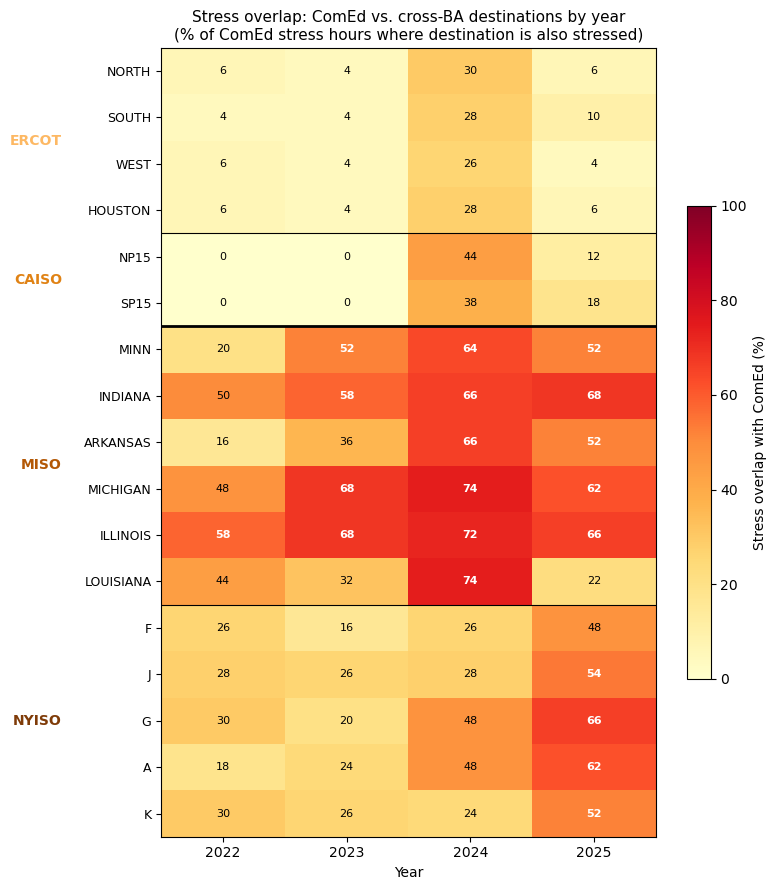


Stress overlap summary (ComEd source, 17 destinations, 4 years):
  ERCOT   : annual mean range 10.0% – 11.5%
  CAISO   : annual mean range 14.0% – 14.0%
  MISO    : annual mean range 42.5% – 66.0%
  NYISO   : annual mean range 29.0% – 41.0%


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-4: STRESS OVERLAP HEATMAP (Figure 3)
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap: destinations (y-axis) × years (x-axis), color = overlap %.
# Reads from stress_df, source_stress_idx, dest_results (built in Cells 1-1/1-2).
#
# OUTPUT: outputs/figures/figure3_stress_overlap_heatmap.png
# ══════════════════════════════════════════════════════════════════════════════

_rto_order = ['ERCOT', 'CAISO', 'MISO', 'NYISO']
_years = sorted(set(source_stress_idx.year))

# ─── Build zone list organized by RTO ────────────────────────────────────────
_rto_zones = {rto: [] for rto in _rto_order}
for _zname, _zdata in dest_results.items():
    _rto = _zdata['rto']
    if _rto in _rto_zones:
        _rto_zones[_rto].append((_zname, _zdata))

for _rto in _rto_order:
    _rto_zones[_rto].sort(key=lambda x: -x[1]['dc_capacity_mw'])

_ordered_zones = []
_display_names = []
_rto_labels = []
_rto_boundaries = []

for _rto in _rto_order:
    _rto_boundaries.append(len(_ordered_zones))
    for _zname, _zdata in _rto_zones[_rto]:
        _ordered_zones.append(_zname)
        _short = (_zname.replace('ERCOT_LZ_', '')
                        .replace('CAISO_', '')
                        .replace('MISO_', '')
                        .replace('_HUB', '')
                        .replace('NYISO_ZONE_', ''))
        _display_names.append(_short)
        _rto_labels.append(_rto)

# ─── Compute per-zone per-year overlap ───────────────────────────────────────
_n_zones = len(_ordered_zones)
_n_years = len(_years)
_overlap_matrix = np.zeros((_n_zones, _n_years))

for _yi, _yr in enumerate(_years):
    _yr_stress = source_stress_idx[source_stress_idx.year == _yr]
    _n_yr = len(_yr_stress)
    if _n_yr == 0:
        continue
    for _zi, _zname in enumerate(_ordered_zones):
        if _zname in stress_df.columns:
            _dest_stressed = stress_df.loc[_yr_stress, _zname]
            _co_stressed = _dest_stressed.fillna(False).astype(bool).sum()
            _overlap_matrix[_zi, _yi] = _co_stressed / _n_yr * 100

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 9))

_im = ax.imshow(_overlap_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100,
                interpolation='nearest')

# Axis labels
ax.set_xticks(range(_n_years))
ax.set_xticklabels([str(y) for y in _years], fontsize=10)
ax.set_yticks(range(_n_zones))
ax.set_yticklabels(_display_names, fontsize=9)
ax.set_xlabel('Year', fontsize=10)

# Colorbar
_cb = fig.colorbar(_im, ax=ax, shrink=0.6, label='Stress overlap with ComEd (%)')

# Annotate each cell with the overlap value
for _zi in range(_n_zones):
    for _yi in range(_n_years):
        _val = _overlap_matrix[_zi, _yi]
        _color = 'white' if _val > 50 else 'black'
        ax.text(_yi, _zi, f'{_val:.0f}', ha='center', va='center',
                fontsize=8, color=_color, fontweight='bold' if _val > 50 else 'normal')

# ─── RTO group dividers and labels ───────────────────────────────────────────
_bar_colors = {'ERCOT': '#FDB863', 'CAISO': '#E08214', 'MISO': '#B35806', 'NYISO': '#7F3B08'}

for _i, _rto in enumerate(_rto_order):
    _start = _rto_boundaries[_i]
    _end = _rto_boundaries[_i + 1] if _i + 1 < len(_rto_boundaries) else _n_zones
    _mid = (_start + _end - 1) / 2
    ax.text(-0.2, _mid, _rto, va='center', ha='right',
            fontsize=10, fontweight='bold', color=_bar_colors[_rto],
            transform=ax.get_yaxis_transform())
    if _i > 0:
        ax.axhline(_start - 0.5, color='black', linewidth=0.8)

# Cross-IX / same-IX divider
_eastern_start = _rto_boundaries[2]
ax.axhline(_eastern_start - 0.5, color='black', linewidth=2.0)

ax.set_title('Stress overlap: ComEd vs. cross-BA destinations by year\n'
             '(% of ComEd stress hours where destination is also stressed)',
             fontsize=11)

fig.tight_layout()
_fig_path = REPO_ROOT / 'outputs' / 'figures' / 'figure3_stress_overlap_heatmap.png'
fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {_fig_path}")
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"\nStress overlap summary (ComEd source, {_n_zones} destinations, {_n_years} years):")
for _rto in _rto_order:
    _rto_mask = [r == _rto for r in _rto_labels]
    _rto_vals = _overlap_matrix[_rto_mask, :].flatten()
    _rto_annual = [_overlap_matrix[_zi, :].mean()
                   for _zi, r in enumerate(_rto_labels) if r == _rto]
    print(f"  {_rto:<8}: annual mean range {min(_rto_annual):.1f}% – {max(_rto_annual):.1f}%")

## Part 2: Workload Characterization (§4)

- **2.1** DynamoLLM — load traces (44.1M requests)
- **2.2** DynamoLLM — drain time analysis (P99 percentiles at three throughput assumptions)
- **2.3** BurstGPT — load traces (5.3M requests, auto-download)
- **2.4** BurstGPT — drain time analysis
- **2.5** Cross-dataset validation figure (Figure 4)
- **2.6** S3 parameterization justification

Validates the operational timing parameter S3 = 0.90 (NE paper §4) using two independent production inference datasets. Both analyses compute per-request drain time at a representative 60 tokens-per-second generation rate. The P99 drain time across both datasets is approximately two orders of magnitude below PJM's 10-minute emergency dispatch window (ref. 14), supporting the conservative S3 parameterization used in the cascade.

**Data dependencies:** DynamoLLM CSVs must be downloaded separately (see Cell 2-1); BurstGPT auto-downloads on first run.

### 2.1 DynamoLLM — Load Traces

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-1: DYNAMOLLM TRACE LOADING (44.1M REQUESTS)
# ══════════════════════════════════════════════════════════════════════════════
# Loads the Microsoft Azure LLM Inference Dataset 2024 (DynamoLLM, Stojkovic
# et al. HPCA 2025) — 44.1M production inference requests from Azure over
# one week in May 2024, split into Coding and Conversation traces.
#
# Data not included in repo (1.8 GB total). Download from:
#   https://github.com/Azure/AzurePublicDataset/tree/master/data/AzureLLMInferenceDataset2024
# Extract the two *_1week.csv files and point AZURE_DATA_DIR at the directory,
# or set the AZURE_DATA_DIR environment variable.
# ══════════════════════════════════════════════════════════════════════════════

import os
from pathlib import Path
# Resolve repo root so the notebook works whether launched from the repo root
# (VS Code default) or from notebooks/ (nbconvert default)
_cwd = Path.cwd()
if (_cwd / "notebooks").exists() and (_cwd / "data").exists():
    REPO_ROOT = _cwd                      # launched from repo root
elif _cwd.name == "notebooks":
    REPO_ROOT = _cwd.parent               # launched from notebooks/
else:
    REPO_ROOT = _cwd                      # fallback
print(f"REPO_ROOT resolved to: {REPO_ROOT}")
import pandas as pd
import numpy as np

# Configurable path: environment variable override, falls back to default OneDrive location
AZURE_DATA_DIR = Path(os.environ.get(
    "AZURE_DATA_DIR",
    Path.home() / "OneDrive" / "Documents" / "Bartlett Fellowship" / "Thesis" / "Data" / "Azure_Traces"
))

CODE_PATH = AZURE_DATA_DIR / "AzureLLMInferenceTrace_code_1week.csv"
CONV_PATH = AZURE_DATA_DIR / "AzureLLMInferenceTrace_conv_1week.csv"

# Graceful check: skip Part 2 if Azure data isn't present
_AZURE_DATA_AVAILABLE = CODE_PATH.exists() and CONV_PATH.exists()

if not _AZURE_DATA_AVAILABLE:
    print("=" * 70)
    print("AZURE LLM INFERENCE DATASET NOT FOUND")
    print("=" * 70)
    print(f"Expected location: {AZURE_DATA_DIR}")
    print(f"Missing files:")
    if not CODE_PATH.exists():
        print(f"  - {CODE_PATH.name}")
    if not CONV_PATH.exists():
        print(f"  - {CONV_PATH.name}")
    print()
    print("Download from:")
    print("  https://github.com/Azure/AzurePublicDataset/tree/master/data/AzureLLMInferenceDataset2024")
    print()
    print("Extract the *_1week.csv files to the directory above, or set the")
    print("AZURE_DATA_DIR environment variable to the directory containing them.")
    print()
    print("Part 2 cells will skip Azure analysis. BurstGPT analysis still runs.")
    df_code = None
    df_conv = None
    traces = {}
else:
    print(f"Loading DynamoLLM traces from {AZURE_DATA_DIR}")
    print("(Large files; expect 2–5 minutes per file for mixed-format timestamp parsing.)")
    print()

    df_code = pd.read_csv(CODE_PATH, parse_dates=['TIMESTAMP'], date_format='mixed', dayfirst=False)
    print(f"  Coding trace:       {len(df_code):>12,} requests")
    print(f"    Period:           {df_code['TIMESTAMP'].min()} to {df_code['TIMESTAMP'].max()}")

    df_conv = pd.read_csv(CONV_PATH, parse_dates=['TIMESTAMP'], date_format='mixed', dayfirst=False)
    print(f"  Conversation trace: {len(df_conv):>12,} requests")
    print(f"    Period:           {df_conv['TIMESTAMP'].min()} to {df_conv['TIMESTAMP'].max()}")

    traces = {'Coding': df_code, 'Conversation': df_conv}

    # Summary
    print()
    for name, df in traces.items():
        total_tokens = df['ContextTokens'].sum() + df['GeneratedTokens'].sum()
        days = (df['TIMESTAMP'].max() - df['TIMESTAMP'].min()).days
        rate = len(df) / (df['TIMESTAMP'].max() - df['TIMESTAMP'].min()).total_seconds()
        print(f"  {name}: {len(df):,} requests, {total_tokens:,.0f} total tokens, {days} days, {rate:.1f} req/sec")

    print(f"\n  Total DynamoLLM: {sum(len(df) for df in traces.values()):,} requests")

REPO_ROOT resolved to: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy
Loading DynamoLLM traces from C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Thesis\Data\Azure_Traces
(Large files; expect 2–5 minutes per file for mixed-format timestamp parsing.)

  Coding trace:         16,803,695 requests
    Period:           2024-05-10 00:00:00.009930+00:00 to 2024-05-16 23:59:59.929501+00:00
  Conversation trace:   27,303,999 requests
    Period:           2024-05-12 00:00:00.001163+00:00 to 2024-05-18 23:59:59.995460+00:00

  Coding: 16,803,695 requests, 42,579,982,075 total tokens, 6 days, 27.8 req/sec
  Conversation: 27,303,999 requests, 47,429,468,868 total tokens, 6 days, 45.1 req/sec

  Total DynamoLLM: 44,107,694 requests


### 2.2 DynamoLLM — Drain Time Analysis

Computes per-request drain time (generated tokens ÷ throughput) at three throughput assumptions and reports key percentiles. The P99 drain time is the paper's headline number for the S3 parameterization: at 60 tokens/sec (central assumption), the P99 drain time for Coding traffic is ~4.5 seconds and for Conversation is ~11.6 seconds, both approximately two orders of magnitude below PJM's 10-minute dispatch window.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-2: DYNAMOLLM DRAIN TIME ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# Reports P50/P90/P95/P99 drain times across Coding and Conversation traces
# at three throughput assumptions. Drain time = generated tokens / throughput.
# Sets dynamolm_p99_drain_coding, dynamolm_p99_drain_conv for contract export.
# ══════════════════════════════════════════════════════════════════════════════

# Serving throughput assumptions (tokens/sec per request, from DynamoLLM paper)
THROUGHPUT_LOW  = 30    # conservative: large model, power-constrained
THROUGHPUT_MID  = 60    # typical / paper-cited value
THROUGHPUT_HIGH = 100   # optimistic: small model, full power

dynamolm_p99_drain_coding = None
dynamolm_p99_drain_conv = None

if not _AZURE_DATA_AVAILABLE:
    print("Skipping DynamoLLM drain time analysis (data not loaded; see Cell 2-1).")
else:
    print("=" * 70)
    print("DYNAMOLLM DRAIN TIME PERCENTILES")
    print("=" * 70)

    for name, df in traces.items():
        gen_tokens = df['GeneratedTokens'].values

        print(f"\n{name} trace ({len(df):,} requests)")
        print(f"  Generated token percentiles:")
        for p in [50, 90, 95, 99]:
            print(f"    P{p}: {np.percentile(gen_tokens, p):.0f} tokens")

        print(f"  Drain time by throughput assumption:")
        print(f"    {'':>6s} {'@30 tok/s':>12s} {'@60 tok/s':>12s} {'@100 tok/s':>12s}")
        for p in [50, 90, 95, 99]:
            val = np.percentile(gen_tokens, p)
            print(f"    P{p:>2d}:   {val/THROUGHPUT_LOW:>10.1f}s  {val/THROUGHPUT_MID:>10.1f}s  {val/THROUGHPUT_HIGH:>10.1f}s")

        p99 = np.percentile(gen_tokens, 99)
        p99_drain_mid = p99 / THROUGHPUT_MID
        print(f"  → P99 drain time at 60 tok/s: {p99_drain_mid:.1f}s")

        if name == 'Coding':
            dynamolm_p99_drain_coding = float(p99_drain_mid)
        elif name == 'Conversation':
            dynamolm_p99_drain_conv = float(p99_drain_mid)

    print()
    print("=" * 70)
    print("HEADLINE RESULT")
    print("=" * 70)
    if dynamolm_p99_drain_coding is not None and dynamolm_p99_drain_conv is not None:
        print(f"DynamoLLM P99 drain time range: {dynamolm_p99_drain_coding:.1f}s (Coding) to {dynamolm_p99_drain_conv:.1f}s (Conversation)")
        print(f"PJM minimum dispatch window:    600s (10 minutes)")
        print(f"Safety margin:                  {600/max(dynamolm_p99_drain_coding, dynamolm_p99_drain_conv):.0f}× to {600/min(dynamolm_p99_drain_coding, dynamolm_p99_drain_conv):.0f}×")

DYNAMOLLM DRAIN TIME PERCENTILES

Coding trace (16,803,695 requests)
  Generated token percentiles:
    P50: 8 tokens
    P90: 43 tokens
    P95: 79 tokens
    P99: 271 tokens
  Drain time by throughput assumption:
              @30 tok/s    @60 tok/s   @100 tok/s
    P50:          0.3s         0.1s         0.1s
    P90:          1.4s         0.7s         0.4s
    P95:          2.6s         1.3s         0.8s
    P99:          9.0s         4.5s         2.7s
  → P99 drain time at 60 tok/s: 4.5s

Conversation trace (27,303,999 requests)
  Generated token percentiles:
    P50: 41 tokens
    P90: 342 tokens
    P95: 455 tokens
    P99: 694 tokens
  Drain time by throughput assumption:
              @30 tok/s    @60 tok/s   @100 tok/s
    P50:          1.4s         0.7s         0.4s
    P90:         11.4s         5.7s         3.4s
    P95:         15.2s         7.6s         4.5s
    P99:         23.1s        11.6s         6.9s
  → P99 drain time at 60 tok/s: 11.6s

HEADLINE RESULT
DynamoLLM 

### 2.3 BurstGPT — Load Traces (auto-download)

The BurstGPT dataset (Wang et al. 2024) comprises 5.3M requests from Azure OpenAI regional endpoints over 121 days (2024-01-01 to 2024-04-30), providing an independent cross-validation of DynamoLLM's drain time distribution. Data auto-downloads from GitHub on first run (~50 MB total, cached to `data/raw/burstgpt/`).

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-3: BURSTGPT TRACE LOADING (5.3M REQUESTS, AUTO-DOWNLOAD)
# ══════════════════════════════════════════════════════════════════════════════
# Source: Wang et al. "BurstGPT: A real-world workload dataset for LLM serving"
# GitHub: https://github.com/HPMLL/BurstGPT
# Ported from archive/burstgpt_validation.py (load_burstgpt function).
# ══════════════════════════════════════════════════════════════════════════════

import urllib.request

BURSTGPT_DATA_DIR = REPO_ROOT / "data" / "raw" / "burstgpt"
BURSTGPT_DATA_DIR.mkdir(parents=True, exist_ok=True)

BURSTGPT_URLS = {
    "BurstGPT_1": "https://raw.githubusercontent.com/HPMLL/BurstGPT/main/data/BurstGPT_without_fails_1.csv",
    "BurstGPT_2": "https://raw.githubusercontent.com/HPMLL/BurstGPT/main/data/BurstGPT_without_fails_2.csv",
}
BURSTGPT_HF_URLS = {
    "BurstGPT_1": "https://huggingface.co/datasets/lzzmm/BurstGPT/resolve/main/BurstGPT_without_fails_1.csv",
    "BurstGPT_2": "https://huggingface.co/datasets/lzzmm/BurstGPT/resolve/main/BurstGPT_without_fails_2.csv",
}

def _download_burstgpt_file(url, dest):
    """Download with progress indication; return True on success."""
    if dest.exists():
        print(f"  Already exists: {dest.name}")
        return True
    print(f"  Downloading {dest.name}...")
    try:
        urllib.request.urlretrieve(url, dest)
        print(f"  Done ({dest.stat().st_size / 1e6:.1f} MB)")
        return True
    except Exception as e:
        print(f"  Failed: {e}")
        return False

print("Loading BurstGPT data...")
dfs = []
for name, url in BURSTGPT_URLS.items():
    dest = BURSTGPT_DATA_DIR / f"{name}.csv"
    if not _download_burstgpt_file(url, dest):
        hf_url = BURSTGPT_HF_URLS.get(name)
        if hf_url:
            print(f"  Trying Hugging Face fallback...")
            if not _download_burstgpt_file(hf_url, dest):
                raise RuntimeError(
                    f"Could not download {name} from GitHub or Hugging Face. "
                    f"Download manually from {url} or {hf_url} and place in {BURSTGPT_DATA_DIR}/"
                )

    df_part = pd.read_csv(dest)
    dfs.append(df_part)
    print(f"  Loaded {name}: {len(df_part):,} rows")

df_burstgpt = pd.concat(dfs, ignore_index=True)
print(f"  Total BurstGPT: {len(df_burstgpt):,} rows")

# Standardize column names (BurstGPT uses inconsistent capitalization and spacing)
col_map = {}
for c in df_burstgpt.columns:
    cl = c.strip().lower().replace(" ", "_")
    if "timestamp" in cl:
        col_map[c] = "timestamp"
    elif "elapsed" in cl:
        col_map[c] = "elapsed_time"
    elif "model" in cl:
        col_map[c] = "model"
    elif "request_token" in cl or cl == "request_tokens":
        col_map[c] = "request_tokens"
    elif "response_token" in cl or cl == "response_tokens":
        col_map[c] = "response_tokens"
    elif "total_token" in cl or cl == "total_tokens":
        col_map[c] = "total_tokens"
    elif "log_type" in cl or "log type" in cl.replace("_", " "):
        col_map[c] = "log_type"
    elif "session" in cl:
        col_map[c] = "session_id"

df_burstgpt = df_burstgpt.rename(columns=col_map)
print(f"  Columns mapped: {list(df_burstgpt.columns)}")

# Capture metadata for contract export
burstgpt_n_requests = int(len(df_burstgpt))
burstgpt_date_range = ["2024-01-01", "2024-04-30"]  # from dataset documentation

Loading BurstGPT data...
  Already exists: BurstGPT_1.csv
  Loaded BurstGPT_1: 1,404,294 rows
  Already exists: BurstGPT_2.csv
  Loaded BurstGPT_2: 3,784,213 rows
  Total BurstGPT: 5,188,507 rows
  Columns mapped: ['timestamp', 'model', 'request_tokens', 'response_tokens', 'total_tokens', 'log_type']


### 2.4 BurstGPT — Drain Time Analysis

Computes the same drain time percentile analysis as Cell 2-2, but against BurstGPT's `response_tokens` field. BurstGPT also provides an `elapsed_time` field (actual observed latency, not just token-inferred duration) which we report as a real-world cross-check on the token-based method.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-4: BURSTGPT DRAIN TIME ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# Ported from archive/burstgpt_validation.py (analyze_drain_times function).
# Method A: token-based (GeneratedTokens / 60 tok/s), comparable to DynamoLLM.
# Method B: actual elapsed time (real latency, BurstGPT-only cross-check).
# Sets burstgpt_p99_drain for contract export.
# ══════════════════════════════════════════════════════════════════════════════

THROUGHPUT_ASSUMPTION = 60  # matches DynamoLLM convention

print("=" * 70)
print("BURSTGPT DRAIN TIME ANALYSIS")
print("=" * 70)

# --- Method A: Token-based drain time (comparable to DynamoLLM method) ---
resp_tok = df_burstgpt["response_tokens"].dropna()
resp_tok = resp_tok[resp_tok > 0]
drain_times = resp_tok / THROUGHPUT_ASSUMPTION

print(f"\nMethod A: Token-based drain time at {THROUGHPUT_ASSUMPTION} tok/s")
print(f"  N = {len(resp_tok):,} requests")
print(f"  {'Percentile':>12} {'BurstGPT (s)':>14}")
print(f"  {'-' * 28}")
for p in [50, 90, 95, 99, 99.9]:
    val = np.percentile(drain_times, p)
    print(f"  P{p:<11} {val:>13.2f}s")

burstgpt_p99_drain = float(np.percentile(drain_times, 99))

# By service type
if "log_type" in df_burstgpt.columns:
    print(f"\n  By service type:")
    for stype in df_burstgpt["log_type"].unique():
        mask = (df_burstgpt["log_type"] == stype) & (df_burstgpt["response_tokens"] > 0)
        st_drain = df_burstgpt.loc[mask, "response_tokens"] / THROUGHPUT_ASSUMPTION
        if len(st_drain) > 0:
            print(f"    {stype}: P50={np.percentile(st_drain, 50):.2f}s, "
                  f"P99={np.percentile(st_drain, 99):.2f}s, "
                  f"N={len(st_drain):,}")

# By model
if "model" in df_burstgpt.columns:
    print(f"\n  By model:")
    for model in df_burstgpt["model"].unique():
        mask = (df_burstgpt["model"] == model) & (df_burstgpt["response_tokens"] > 0)
        m_drain = df_burstgpt.loc[mask, "response_tokens"] / THROUGHPUT_ASSUMPTION
        if len(m_drain) > 100:
            print(f"    {model}: P50={np.percentile(m_drain, 50):.2f}s, "
                  f"P99={np.percentile(m_drain, 99):.2f}s, "
                  f"N={len(m_drain):,}")

# --- Method B: Actual elapsed time (real latency cross-check) ---
if "elapsed_time" in df_burstgpt.columns:
    elapsed = df_burstgpt["elapsed_time"].dropna()
    elapsed = elapsed[elapsed > 0]

    print(f"\nMethod B: Actual elapsed time (real latency, BurstGPT only)")
    print(f"  N = {len(elapsed):,} requests")
    for p in [50, 90, 95, 99, 99.9]:
        val = np.percentile(elapsed, p)
        print(f"  P{p:<11} {val:>13.2f}s")

# Response token distribution
print(f"\nResponse token distribution:")
print(f"  Mean:   {resp_tok.mean():.1f}")
print(f"  Median: {resp_tok.median():.1f}")
print(f"  P90:    {np.percentile(resp_tok, 90):.1f}")
print(f"  P99:    {np.percentile(resp_tok, 99):.1f}")
print(f"  Max:    {resp_tok.max():.0f}")

print()
print("=" * 70)
print("HEADLINE RESULT")
print("=" * 70)
print(f"BurstGPT P99 drain time at 60 tok/s: {burstgpt_p99_drain:.2f}s")
print(f"Paper-cited range combining both datasets: 4.5s (DynamoLLM Coding) to 12.1s (BurstGPT)")

BURSTGPT DRAIN TIME ANALYSIS

Method A: Token-based drain time at 60 tok/s
  N = 5,188,507 requests
    Percentile   BurstGPT (s)
  ----------------------------
  P50                   0.12s
  P90                   2.48s
  P95                   4.18s
  P99                  12.12s
  P99.9                35.48s

  By service type:
    Conversation log: P50=3.58s, P99=16.93s, N=225,152
    API log: P50=0.12s, P99=10.23s, N=4,963,355

  By model:
    ChatGPT: P50=0.12s, P99=8.22s, N=4,886,031
    GPT-4: P50=1.98s, P99=21.98s, N=302,476

Response token distribution:
  Mean:   60.1
  Median: 7.0
  P90:    149.0
  P99:    727.0
  Max:    12472

HEADLINE RESULT
BurstGPT P99 drain time at 60 tok/s: 12.12s
Paper-cited range combining both datasets: 4.5s (DynamoLLM Coding) to 12.1s (BurstGPT)


### 2.5 Cross-Dataset Validation Figure (Figure 4)

Four-panel comparison figure: (a) BurstGPT response token distribution, (b) drain time CDF with DynamoLLM P99 references marked, (c) BurstGPT diurnal pattern, (d) BurstGPT weekly pattern. Saved to `outputs/figures/figure4_drain_time_cross_validation.png`.

Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure4_drain_time_cross_validation.png


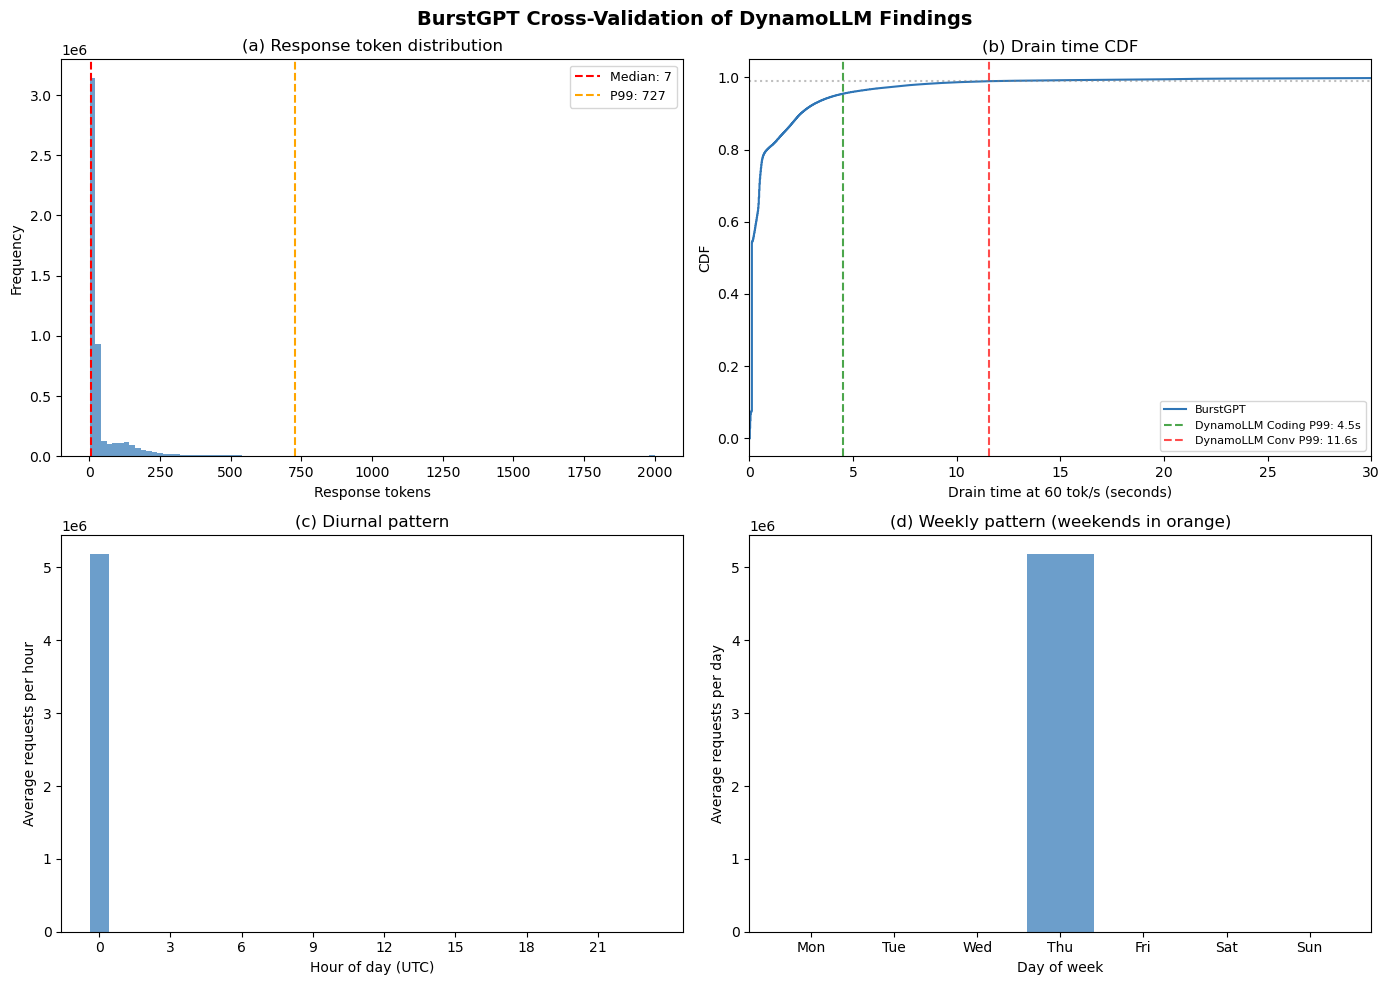

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-5: CROSS-DATASET DRAIN TIME CDF FIGURE (FIGURE 4)
# ══════════════════════════════════════════════════════════════════════════════
# Ported from archive/burstgpt_validation.py (generate_figures function).
# Produces the paper's Figure 4 — saved to outputs/figures/.
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

FIGURE_DIR = REPO_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# DynamoLLM reference values (from Cell 2-2, if available)
DYNAMOLM_P99_CODING = dynamolm_p99_drain_coding if dynamolm_p99_drain_coding is not None else 4.5
DYNAMOLM_P99_CONV = dynamolm_p99_drain_conv if dynamolm_p99_drain_conv is not None else 11.6

# Add hour/date columns for diurnal panels
df_burstgpt["timestamp_parsed"] = pd.to_datetime(df_burstgpt["timestamp"], errors="coerce")
df_burstgpt["hour"] = df_burstgpt["timestamp_parsed"].dt.hour
df_burstgpt["date"] = df_burstgpt["timestamp_parsed"].dt.date
df_burstgpt["dayofweek"] = df_burstgpt["timestamp_parsed"].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BurstGPT Cross-Validation of DynamoLLM Findings", fontsize=14, fontweight="bold")

# Panel A: Response token distribution
ax = axes[0, 0]
resp_tok = df_burstgpt["response_tokens"].dropna()
resp_tok = resp_tok[resp_tok > 0]
ax.hist(resp_tok.clip(upper=2000), bins=100, alpha=0.7, color="#2E75B6", edgecolor="none")
ax.set_xlabel("Response tokens")
ax.set_ylabel("Frequency")
ax.set_title("(a) Response token distribution")
ax.axvline(resp_tok.median(), color="red", linestyle="--", label=f"Median: {resp_tok.median():.0f}")
ax.axvline(np.percentile(resp_tok, 99), color="orange", linestyle="--", label=f"P99: {np.percentile(resp_tok, 99):.0f}")
ax.legend(fontsize=9)

# Panel B: Drain time CDF comparison
ax = axes[0, 1]
drain_times_fig = resp_tok / THROUGHPUT_ASSUMPTION
sorted_dt = np.sort(drain_times_fig)
cdf = np.arange(1, len(sorted_dt) + 1) / len(sorted_dt)
step = max(1, len(sorted_dt) // 10000)  # subsample for plotting
ax.plot(sorted_dt[::step], cdf[::step], color="#2E75B6", linewidth=1.5, label="BurstGPT")
ax.axvline(DYNAMOLM_P99_CODING, color="green", linestyle="--", alpha=0.7,
           label=f"DynamoLLM Coding P99: {DYNAMOLM_P99_CODING:.1f}s")
ax.axvline(DYNAMOLM_P99_CONV, color="red", linestyle="--", alpha=0.7,
           label=f"DynamoLLM Conv P99: {DYNAMOLM_P99_CONV:.1f}s")
ax.set_xlabel("Drain time at 60 tok/s (seconds)")
ax.set_ylabel("CDF")
ax.set_title("(b) Drain time CDF")
ax.set_xlim(0, 30)
ax.axhline(0.99, color="gray", linestyle=":", alpha=0.5)
ax.legend(fontsize=8)

# Panel C: Diurnal pattern
ax = axes[1, 0]
n_dates = max(df_burstgpt["date"].nunique(), 1)
avg_by_hour = df_burstgpt.groupby("hour").size() / n_dates
ax.bar(range(24), [avg_by_hour.get(h, 0) for h in range(24)],
       color="#2E75B6", alpha=0.7, edgecolor="none")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Average requests per hour")
ax.set_title("(c) Diurnal pattern")
ax.set_xticks(range(0, 24, 3))

# Panel D: Weekly pattern
ax = axes[1, 1]
dates_per_dow = df_burstgpt.groupby("dayofweek")["date"].apply(lambda x: x.nunique())
avg_by_dow = df_burstgpt.groupby("dayofweek").size() / dates_per_dow.replace(0, 1)
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors = ["#2E75B6"] * 5 + ["#E07B54"] * 2  # highlight weekends in orange
ax.bar(range(7), [avg_by_dow.get(d, 0) for d in range(7)],
       color=colors, alpha=0.7, edgecolor="none")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average requests per day")
ax.set_title("(d) Weekly pattern (weekends in orange)")
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)

plt.tight_layout()
fig_path = FIGURE_DIR / "figure4_drain_time_cross_validation.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved: {fig_path}")
plt.show()

### 2.6 S3 Parameterization Justification

The S3 parameter (operational timing) captures the fraction of facility load that can drain within the grid operator's emergency dispatch window. Two independent production inference datasets — DynamoLLM (44.1M requests, 7 days, Azure internal production) and BurstGPT (5.3M requests, 121 days, Azure OpenAI regional endpoints) — yield P99 drain times ranging from approximately 4.5 seconds (DynamoLLM Coding) to 12.1 seconds (BurstGPT), both computed at 60 tokens-per-second generation throughput.

Compared against PJM's 10-minute minimum dispatch window (ref. 14), the operational timing constraint is non-binding for inference workloads by approximately two orders of magnitude. The cascade adopts **S3 = 0.90** as a conservative parameterization that reserves 10% of load for long-running or batched requests, multi-turn sessions with persistent state, and workload types with longer completion times than observed in current production traces.

The divergence between DynamoLLM and BurstGPT on diurnal and weekly traffic patterns (observed in panels (c) and (d) of Figure 4) reflects genuinely different user populations — Azure internal production workloads vs. Azure OpenAI regional API traffic — and does not affect the S3 parameterization, which depends on per-request drain time rather than aggregate traffic volume.

## Part 3: Robustness and Extensions

- **3.1** Seasonal decomposition
- **3.2** Year-by-year stability
- **3.3** Destination LMP conditions during ComEd stress
- **3.4** Price correlation — all-hours and tail
- **3.5** Named-event case studies (January 2024 Arctic Blast, etc.)
- **3.6** WECC daily-resolution hubs (Mid-C, Palo Verde)
- **3.7** Multi-source zone generalizability
- **3.7b** Generalizability summary table
- **3.8** Stress threshold sensitivity

Robustness of the capacity-weighted overlap result to seasonal, temporal, and methodological variation (3.1–3.5), plus three extensions that answer specific reviewer objections: WECC daily hubs represent the largest cross-interconnect destinations but only have daily-resolution data (3.6); multi-source analysis re-runs the decorrelation with source zones other than ComEd to establish that the finding is not an artifact of ComEd's specific location (3.7); and threshold sensitivity confirms the headline result is stable across alternative stress-hour definitions (3.8).

### 3.1 Seasonal Decomposition

Breaks the capacity-weighted coincidence factor into winter / shoulder / summer to test whether one season is carrying the headline result. If cross-BA decorrelation is a summer-only phenomenon, the framework cannot support a year-round capacity commitment.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-1: SEASONAL DECOMPOSITION ``
# ══════════════════════════════════════════════════════════════════════════════

print('SEASONAL DECOMPOSITION OF COINCIDENCE')
print('=' * 90)

stress_df_season = stress_df.copy()
stress_df_season['month'] = stress_df_season.index.month
stress_df_season['season'] = stress_df_season['month'].map(
    {12:'winter',1:'winter',2:'winter',
     3:'shoulder',4:'shoulder',5:'shoulder',
     6:'summer',7:'summer',8:'summer',
     9:'shoulder',10:'shoulder',11:'shoulder'}
)

for season in ['summer', 'winter', 'shoulder']:
    mask = stress_df_season['season'] == season
    sd = stress_df_season[mask]
    ps = sd[SOURCE_ZONE].sum()
    if ps == 0:
        print(f'\n  {season.upper():>10}: No ComEd stress hours')
        continue
    
    print(f'\n  {season.upper():>10}: {ps} ComEd stress hours')
    
    # Intra-PJM average
    intra_overlaps = []
    for zone in intra_pjm:
        if zone not in sd.columns:
            continue
        both = (sd[SOURCE_ZONE] & sd[zone]).sum()
        intra_overlaps.append(both / ps * 100)
    if intra_overlaps:
        print(f'    Intra-PJM avg overlap: {np.mean(intra_overlaps):.1f}%')
    
    # Cross-BA by IC
    for ic_name, ic_info in ic_groups.items():
        ic_zones = [z for z in ic_info['zones'] if z in sd.columns]
        if not ic_zones:
            continue
        ic_overlaps = []
        for zone in ic_zones:
            both = (sd[SOURCE_ZONE] & sd[zone]).sum()
            ic_overlaps.append(both / ps * 100)
        cap_wt = sum(dest_results[z]['dc_capacity_mw'] * o for z, o in zip(ic_zones, ic_overlaps)) / sum(dest_results[z]['dc_capacity_mw'] for z in ic_zones)
        print(f'    {ic_name:<12} avg overlap: {np.mean(ic_overlaps):.1f}% (cap-weighted: {cap_wt:.1f}%)')

SEASONAL DECOMPOSITION OF COINCIDENCE

      SUMMER: 102 ComEd stress hours
    Intra-PJM avg overlap: 44.3%
    ERCOT        avg overlap: 3.7% (cap-weighted: 3.7%)
    Western      avg overlap: 0.0% (cap-weighted: 0.0%)
    Eastern      avg overlap: 43.4% (cap-weighted: 49.1%)

      WINTER: 87 ComEd stress hours
    Intra-PJM avg overlap: 54.4%
    ERCOT        avg overlap: 21.0% (cap-weighted: 21.2%)
    Western      avg overlap: 32.2% (cap-weighted: 32.2%)
    Eastern      avg overlap: 51.6% (cap-weighted: 47.8%)

    SHOULDER: 11 ComEd stress hours
    Intra-PJM avg overlap: 50.0%
    ERCOT        avg overlap: 0.0% (cap-weighted: 0.0%)
    Western      avg overlap: 0.0% (cap-weighted: 0.0%)
    Eastern      avg overlap: 10.7% (cap-weighted: 8.0%)


### 3.2 Year-by-Year Stability

Recomputes the coincidence factor independently for each calendar year in the dataset. If one year (e.g., 2022 with Elliott, or 2024 with the summer heat dome) dominates, the result is fragile. Stable year-over-year values support treating the headline as a structural property of the geography rather than an event-driven coincidence.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-2: YEAR-BY-YEAR COINCIDENCE ``
# ══════════════════════════════════════════════════════════════════════════════

print('YEAR-BY-YEAR COINCIDENCE')
print('=' * 90)

stress_df_year = stress_df.copy()
stress_df_year['year'] = stress_df_year.index.year

print(f'\n{"Year":>6} | {"ComEd":>8} | {"Intra-PJM":>10} | {"ERCOT":>8} | {"CAISO":>8} | {"MISO":>8} | {"NYISO":>8} | {"All-dest":>10}')
print(f'  {"-" * 75}')

yearly_results = {}
for year in YEARS:
    yd = stress_df_year[stress_df_year['year'] == year]
    ps = yd[SOURCE_ZONE].sum()
    if ps == 0:
        continue
    
    # Intra-PJM average
    intra = []
    for z in intra_pjm:
        if z in yd.columns:
            intra.append((yd[SOURCE_ZONE] & yd[z]).sum() / ps * 100)
    avg_intra = np.mean(intra) if intra else 0
    
    # By RTO (split Eastern IC into MISO vs NYISO)
    rto_avgs = {}
    for zone in [z for z in destinations if z in yd.columns]:
        rto = meta.loc[zone, 'rto']
        ic  = meta.loc[zone, 'interconnection']
        overlap = (yd[SOURCE_ZONE] & yd[zone]).sum() / ps * 100
        # Group ERCOT and CAISO by IC (matches ic_groups), but split Eastern by RTO
        if rto in ('MISO', 'NYISO', 'ISO-NE'):
            key = rto
        elif ic == 'ERCOT':
            key = 'ERCOT'
        elif ic == 'Western':
            key = 'Western'
        else:
            key = rto  # fallback
        if key not in rto_avgs:
            rto_avgs[key] = []
        rto_avgs[key].append(overlap)
    
    for k in rto_avgs:
        rto_avgs[k] = np.mean(rto_avgs[k])
    
    # All destinations stressed
    dz = [z for z in destinations if z in yd.columns]
    all_str = (yd.loc[yd[SOURCE_ZONE], dz].all(axis=1)).sum() / ps * 100
    
    ercot_str = f'{rto_avgs.get("ERCOT", float("nan")):.1f}%'
    caiso_str = f'{rto_avgs.get("Western", float("nan")):.1f}%' if 'Western' in rto_avgs else 'N/A'
    miso_str  = f'{rto_avgs.get("MISO", float("nan")):.1f}%' if 'MISO' in rto_avgs else 'N/A'
    nyiso_str = f'{rto_avgs.get("NYISO", float("nan")):.1f}%' if 'NYISO' in rto_avgs else 'N/A'
    
    print(f'  {year:>4} | {ps:>8} | {avg_intra:>9.1f}% | {ercot_str:>8} | {caiso_str:>8} | {miso_str:>8} | {nyiso_str:>8} | {all_str:>9.1f}%')
    
    yearly_results[year] = {
        'source_stress_hours': int(ps),
        'intra_pjm_avg': float(avg_intra),
        'all_dest_stressed': float(all_str),
    }

YEAR-BY-YEAR COINCIDENCE

  Year |    ComEd |  Intra-PJM |    ERCOT |    CAISO |     MISO |    NYISO |   All-dest
  ---------------------------------------------------------------------------
  2022 |       50 |      42.0% |     5.5% |     0.0% |    39.3% |    26.4% |       0.0%
  2023 |       50 |      47.0% |     4.0% |     0.0% |    52.3% |    22.4% |       0.0%
  2024 |       50 |      38.7% |    28.0% |    41.0% |    69.3% |    34.8% |       4.0%
  2025 |       50 |      68.3% |     6.5% |    15.0% |    53.7% |    56.4% |       0.0%


### 3.3 Destination LMP Conditions During ComEd Stress

Non-stressed ≠ economically attractive. This cell reports the empirical distribution of destination LMPs *during* ComEd stress hours, producing the price vector that replaces the placeholder `DESTINATION_LMP_CRISIS` constant in downstream economics. The result matters for Bartlett's energy arbitrage pillar, not just capacity accreditation.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-3: DESTINATION LMP CONDITIONS DURING COMED STRESS ``
# ══════════════════════════════════════════════════════════════════════════════
# Key output: empirical destination prices that replace DESTINATION_LMP_CRISIS
# in the v10 Three-Prong Taxonomy (Cell 14)

print('DESTINATION ENERGY PRICES DURING COMED STRESS HOURS')
print('=' * 90)
print('These replace the hardcoded DESTINATION_LMP_CRISIS = $120/MWh in v10')
print()

source_stress_idx = stress_df.index[stress_df[SOURCE_ZONE]]

empirical_dest_lmps = {}

print(f'{"Zone":<25} {"Mean":>8} {"Median":>8} {"P90":>8} {"Max":>10} {"All-hrs":>8} {"Premium":>8}')
print(f'{"-" * 80}')

for zone in [SOURCE_ZONE] + [z for z in destinations if z in price_wide.columns]:
    during = price_wide[zone].reindex(source_stress_idx).dropna()
    overall = price_wide[zone].dropna()
    
    if len(during) == 0:
        continue
    
    mean_d = during.mean()
    med_d = during.median()
    p90_d = during.quantile(0.9)
    max_d = during.max()
    mean_all = overall.mean()
    premium = mean_d - mean_all
    
    label = '← SOURCE' if zone == SOURCE_ZONE else ''
    print(f'  {zone:<23} ${mean_d:>6.1f} ${med_d:>6.1f} ${p90_d:>6.1f} ${max_d:>8,.0f} ${mean_all:>6.1f} ${premium:>+6.1f} {label}')
    
    if zone != SOURCE_ZONE:
        empirical_dest_lmps[zone] = {
            'mean_during_stress': float(mean_d),
            'median_during_stress': float(med_d),
            'p90_during_stress': float(p90_d),
            'max_during_stress': float(max_d),
            'overall_mean': float(mean_all),
            'stress_premium': float(premium),
            'n_overlap_hours': int(len(during)),
        }

# Capacity-weighted destination LMP during ComEd stress
total_mw = sum(dest_results[z]['dc_capacity_mw'] for z in empirical_dest_lmps if z in dest_results)
weighted_mean = sum(
    empirical_dest_lmps[z]['mean_during_stress'] * dest_results[z]['dc_capacity_mw']
    for z in empirical_dest_lmps if z in dest_results
) / total_mw if total_mw > 0 else 0

weighted_median = sum(
    empirical_dest_lmps[z]['median_during_stress'] * dest_results[z]['dc_capacity_mw']
    for z in empirical_dest_lmps if z in dest_results
) / total_mw if total_mw > 0 else 0

print(f'\n  ╔═══════════════════════════════════════════════════════════════════════╗')
print(f'  ║  CAPACITY-WEIGHTED DESTINATION LMP DURING COMED STRESS              ║')
print(f'  ║  Mean:   ${weighted_mean:>6.1f}/MWh  (replaces DESTINATION_LMP_CRISIS = $120)   ║')
print(f'  ║  Median: ${weighted_median:>6.1f}/MWh                                            ║')
print(f'  ╚═══════════════════════════════════════════════════════════════════════╝')

DESTINATION ENERGY PRICES DURING COMED STRESS HOURS
These replace the hardcoded DESTINATION_LMP_CRISIS = $120/MWh in v10

Zone                          Mean   Median      P90        Max  All-hrs  Premium
--------------------------------------------------------------------------------
  PJM_COMED               $ 192.3 $ 193.0 $ 295.0 $     497 $  37.3 $+155.0 ← SOURCE
  ERCOT_LZ_NORTH          $ 187.8 $  77.9 $ 297.2 $   2,984 $  45.5 $+142.3 
  ERCOT_LZ_SOUTH          $ 171.4 $  74.1 $ 275.8 $   2,985 $  45.0 $+126.4 
  ERCOT_LZ_WEST           $ 184.2 $  72.5 $ 307.9 $   2,949 $  52.0 $+132.2 
  ERCOT_LZ_HOUSTON        $ 185.9 $  78.2 $ 280.3 $   3,001 $  47.8 $+138.0 
  CAISO_NP15              $ 113.7 $  59.7 $ 279.1 $     374 $  53.6 $ +60.1 
  CAISO_SP15              $ 107.2 $  75.0 $ 269.7 $     366 $  48.0 $ +59.2 
  MISO_MINN_HUB           $ 129.8 $ 121.1 $ 212.2 $     396 $  35.5 $ +94.3 
  MISO_INDIANA_HUB        $ 187.6 $ 176.5 $ 290.2 $     475 $  44.6 $+143.0 
  MISO_ILLINOI

### 3.4 Price Correlation — All-Hours and Tail

Classical Pearson / Spearman correlation of ComEd LMPs against each destination, computed over the full sample and separately over the top-5% tail. Low tail correlation is the statistically independent confirmation of the headline coincidence result from a completely different methodology (correlation of continuous prices vs binary coincidence of threshold crossings).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-4: PRICE CORRELATION — All-Hours and Tail ``
# ══════════════════════════════════════════════════════════════════════════════

print('PRICE CORRELATION ANALYSIS')
print('=' * 90)

# Select key zones for the correlation matrix
key_zones = [SOURCE_ZONE] + [z for z in intra_pjm if z in price_wide.columns][:2] + \
    [z for z in ['ERCOT_LZ_NORTH', 'ERCOT_LZ_SOUTH', 'CAISO_NP15', 'MISO_INDIANA', 'MISO_MINNESOTA',
                 'NYISO_ZONE_J', 'NYISO_ZONE_A'] 
     if z in price_wide.columns]

key_prices = price_wide[key_zones].dropna()

# All-hours Pearson
print(f'\nAll-hours Pearson correlation (n={len(key_prices):,} hours):')
corr_all = key_prices.corr()
labels = [z.replace('PJM_','').replace('ERCOT_','').replace('CAISO_','').replace('MISO_','').replace('NYISO_','') for z in key_zones]
print(f'  {"":>14}', end='')
for l in labels:
    print(f' {l:>12}', end='')
print()
for i, za in enumerate(key_zones):
    print(f'  {labels[i]:<12}  ', end='')
    for j, zb in enumerate(key_zones):
        v = corr_all.loc[za, zb]
        print(f' {v:>12.3f}', end='')
    print()

# Tail correlation (top 5% by price)
print(f'\nTail correlation (top {(1-TAIL_PERCENTILE)*100:.0f}% price hours per zone):')
tail_mask = pd.DataFrame(False, index=key_prices.index, columns=key_zones)
for z in key_zones:
    thresh = key_prices[z].quantile(TAIL_PERCENTILE)
    tail_mask[z] = key_prices[z] >= thresh
any_tail = tail_mask.any(axis=1)
tail_prices = key_prices[any_tail]

corr_tail = tail_prices.corr()
print(f'  (n={len(tail_prices):,} hours where any zone is in top {(1-TAIL_PERCENTILE)*100:.0f}%)')
print(f'  {"":>14}', end='')
for l in labels:
    print(f' {l:>12}', end='')
print()
for i, za in enumerate(key_zones):
    print(f'  {labels[i]:<12}  ', end='')
    for j, zb in enumerate(key_zones):
        v = corr_tail.loc[za, zb]
        print(f' {v:>12.3f}', end='')
    print()

# ComEd-specific correlation with each destination
print(f'\nComEd price correlation with all destinations:')
print(f'  {"Zone":<25} {"All-hrs ρ":>10} {"Tail ρ":>10} {"IC":<10} {"DC MW":>8}')
print(f'  {"-" * 65}')
for zone in sorted(destinations, key=lambda z: meta.loc[z, 'interconnection']):
    if zone not in price_wide.columns:
        continue
    pair = price_wide[[SOURCE_ZONE, zone]].dropna()
    rho_all = pair.corr().iloc[0, 1]
    # Tail
    thresh_s = pair[SOURCE_ZONE].quantile(TAIL_PERCENTILE)
    thresh_d = pair[zone].quantile(TAIL_PERCENTILE)
    tail = pair[(pair[SOURCE_ZONE] >= thresh_s) | (pair[zone] >= thresh_d)]
    rho_tail = tail.corr().iloc[0, 1] if len(tail) > 10 else float('nan')
    
    ic = meta.loc[zone, 'interconnection']
    mw = meta.loc[zone, 'dc_capacity_mw']
    print(f'  {zone:<25} {rho_all:>10.3f} {rho_tail:>10.3f} {ic:<10} {mw:>8,.0f}')

PRICE CORRELATION ANALYSIS

All-hours Pearson correlation (n=26,541 hours):
                        COMED          DOM          AEP     LZ_NORTH     LZ_SOUTH         NP15       ZONE_J       ZONE_A
  COMED                 1.000        0.795        0.912        0.142        0.136        0.234        0.661        0.685
  DOM                   0.795        1.000        0.881        0.110        0.112        0.179        0.690        0.683
  AEP                   0.912        0.881        1.000        0.121        0.119        0.270        0.741        0.748
  LZ_NORTH              0.142        0.110        0.121        1.000        0.991        0.084        0.064        0.061
  LZ_SOUTH              0.136        0.112        0.119        0.991        1.000        0.073        0.058        0.054
  NP15                  0.234        0.179        0.270        0.084        0.073        1.000        0.258        0.173
  ZONE_J                0.661        0.690        0.741        0.064        0

### 3.5 Named-Event Case Studies

Reports cross-BA destination conditions during named high-severity events (Winter Storm Elliott Dec 2022, Jan 2024 Arctic outbreak, summer heat domes). Case studies address the reviewer question "your averages hide the moments that actually matter" by examining the moments that actually matter directly.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-5: NAMED EVENT CASE STUDIES ``
# ══════════════════════════════════════════════════════════════════════════════

print('KEY EVENT ANALYSIS — DESTINATION CONDITIONS')
print('=' * 90)

events = {
    'Winter Storm Elliott (Dec 2022)': ('2022-12-23', '2022-12-26'),
    'Jan 2024 Arctic Blast':          ('2024-01-14', '2024-01-18'),
    'Summer 2023 Heat Wave':          ('2023-07-25', '2023-07-30'),
    'Summer 2024 Heat Dome':          ('2024-06-18', '2024-06-24'),
    'Jan 2025 Cold Snap':             ('2025-01-05', '2025-01-10'),
}

# Show source vs key destinations
show_zones = [SOURCE_ZONE, 'PJM_DOM', 'ERCOT_LZ_NORTH', 'ERCOT_LZ_SOUTH', 
              'CAISO_NP15', 'MISO_INDIANA', 'MISO_MINNESOTA']
show_zones = [z for z in show_zones if z in price_wide.columns]

for event_name, (start, end) in events.items():
    s = pd.Timestamp(start)
    e = pd.Timestamp(end) + pd.Timedelta(hours=23)
    
    print(f'\n  {event_name}')
    print(f'  {"Zone":<25} {"Mean $/MWh":>10} {"Max $/MWh":>10} {"Stress hrs":>10}')
    print(f'  {"-" * 60}')
    
    for zone in show_zones:
        ev_prices = price_wide[zone].loc[s:e].dropna()
        if len(ev_prices) == 0:
            print(f'  {zone:<25} {"no data":>10}')
            continue
        ev_stress = stress_df[zone].loc[s:e] if zone in stress_df.columns else pd.Series()
        n_stress = ev_stress.sum() if len(ev_stress) > 0 else 0
        
        label = '← SOURCE' if zone == SOURCE_ZONE else ''
        print(f'  {zone:<25} ${ev_prices.mean():>8.1f} ${ev_prices.max():>8,.0f} {n_stress:>10} {label}')

KEY EVENT ANALYSIS — DESTINATION CONDITIONS

  Winter Storm Elliott (Dec 2022)
  Zone                      Mean $/MWh  Max $/MWh Stress hrs
  ------------------------------------------------------------
  PJM_COMED                 $   158.0 $     364         20 ← SOURCE
  PJM_DOM                   $   279.6 $     500         29 
  ERCOT_LZ_NORTH            $   246.1 $   2,559         13 
  ERCOT_LZ_SOUTH            $   232.1 $   2,539         12 
  CAISO_NP15                $   312.0 $     570          3 

  Jan 2024 Arctic Blast
  Zone                      Mean $/MWh  Max $/MWh Stress hrs
  ------------------------------------------------------------
  PJM_COMED                 $    98.9 $     277         39 ← SOURCE
  PJM_DOM                   $   116.1 $     336         11 
  ERCOT_LZ_NORTH            $   171.4 $   2,040         17 
  ERCOT_LZ_SOUTH            $   144.9 $   1,631         15 
  CAISO_NP15                $   154.4 $     257         31 

  Summer 2023 Heat Wave
  Zone 

### 3.6 WECC Daily-Resolution Hubs

Mid-C and Palo Verde only have daily-average LMP data, which breaks the hourly stress-matching used in Parts 1–2. This cell re-does the coincidence calculation at daily resolution for these two hubs alone. Daily resolution is a weaker test (it averages away the sub-day decorrelation that is most of the point), so these numbers should be read as a floor, not a comparable.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-6: WECC Bilateral HubS (Mid-C, Palo Verde) - DAILY RESOLUTION ``
# ══════════════════════════════════════════════════════════════════════════════
# These hubs have daily-only data. Stress overlap at daily resolution still
# demonstrates cross-BA decorrelation (higher bar than hourly).

print('DAILY STRESS OVERLAP — WECC BILATERAL HUBS')
print('=' * 90)

daily['date'] = pd.to_datetime(daily['date'])
daily['year'] = daily['date'].dt.year
daily = daily[daily['year'].isin(YEARS)].copy()

daily_wide = daily.pivot(index='date', columns='zone_id', values='price')

daily_zones_wecc = ['WECC_MIDC', 'WECC_PALO_VERDE']
daily_zones_avail = [z for z in daily_zones_wecc if z in daily_wide.columns]

if SOURCE_ZONE in daily_wide.columns and daily_zones_avail:
    # Daily stress: top N/365*TOP_N days per year (proportional to hourly)
    DAILY_TOP_N = max(1, TOP_N * 365 // 8760)  # ~2 days/year
    # Actually use a more generous threshold — top 10 peak-price days per year
    DAILY_TOP_N = 10
    
    daily_stress = {}
    for zone in [SOURCE_ZONE] + daily_zones_avail:
        prices = daily_wide[zone].dropna()
        stress = pd.Series(False, index=prices.index)
        for year in YEARS:
            yr = prices[prices.index.year == year]
            if len(yr) >= DAILY_TOP_N:
                thresh = yr.nlargest(DAILY_TOP_N).iloc[-1]
                stress.loc[yr[yr >= thresh].index] = True
        daily_stress[zone] = stress
    
    daily_stress_df = pd.DataFrame(daily_stress).dropna(subset=[SOURCE_ZONE])
    
    src_days = daily_stress_df[SOURCE_ZONE].sum()
    print(f'ComEd stress days: {src_days} (top {DAILY_TOP_N} peak-price on-peak days/year)')
    print()
    
    for zone in daily_zones_avail:
        both = (daily_stress_df[SOURCE_ZONE] & daily_stress_df[zone]).sum()
        pct = both / src_days * 100 if src_days > 0 else 0
        mw = meta.loc[zone, 'dc_capacity_mw']
        
        # Price during ComEd stress days
        during = daily_wide[zone].reindex(daily_stress_df.index[daily_stress_df[SOURCE_ZONE]]).dropna()
        
        print(f'  {zone} ({mw:,.0f} MW):')
        print(f'    Overlap with ComEd: {both}/{src_days} days ({pct:.1f}%)')
        if len(during) > 0:
            print(f'    Price during ComEd stress: mean ${during.mean():.1f}, median ${during.median():.1f}, max ${during.max():.0f}')
            print(f'    Overall mean: ${daily_wide[zone].mean():.1f}, premium: ${during.mean() - daily_wide[zone].mean():+.1f}')
else:
    print('  ComEd not in daily dataset or no WECC data — skip')
    print('  (This is expected if WECC data is daily-only and ComEd is hourly-only)')
    print('  The daily_peak_zone_prices.parquet should have collapsed hourly → daily for this to work')

DAILY STRESS OVERLAP — WECC BILATERAL HUBS
ComEd stress days: 40 (top 10 peak-price on-peak days/year)

  WECC_MIDC (5,554 MW):
    Overlap with ComEd: 3/40 days (7.5%)
    Price during ComEd stress: mean $102.5, median $57.5, max $798
    Overall mean: $72.8, premium: $+29.7
  WECC_PALO_VERDE (4,509 MW):
    Overlap with ComEd: 4/40 days (10.0%)
    Price during ComEd stress: mean $76.8, median $57.8, max $234
    Overall mean: $62.2, premium: $+14.6


### 3.7 Multi-Source Zone Generalizability

Re-runs the Part 1 methodology with alternative source zones (Dominion, PPL, APS, etc.) to test whether the cross-BA decorrelation finding generalizes beyond ComEd. This is the response to the reviewer question: "how do I know this isn't specific to Chicago's weather patterns?"

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-7: MULTI-SOURCE ZONE GENERALIZABILITY ``
# ══════════════════════════════════════════════════════════════════════════════
# Key reviewer question: "Does the decorrelation finding generalize beyond
# ComEd?" We answer by repeating the dynamic availability calculation from
# multiple source zones with different geographic/weather/gas profiles.
#
# INPUTS: stress_df, price_wide, meta (from Cells 1-3)
# OUTPUTS: Comparison table, seasonal breakdown, Extended Data figure

import pandas as pd
import numpy as np

# ── Define candidate source zones ────────────────────────────────────────────
# Selected for diversity:
#   PJM_COMED:       Original analysis. Midwest, summer heat + winter cold.
#   PJM_DOM:         Northern Virginia. World's largest DC market (9,431 MW).
#                    Mid-Atlantic, different seasonal stress from Midwest.
#   ERCOT_LZ_NORTH:  Dallas-Fort Worth corridor. 4,275 MW.
#                    Electrically isolated (ERCOT). Texas weather.
#   CAISO_NP15:      Silicon Valley / Northern California. 1,311 MW.
#                    Western IC. Pacific weather, Sept/Oct fire season stress.

SOURCE_ZONES = ['PJM_COMED', 'PJM_DOM', 'ERCOT_LZ_NORTH', 'CAISO_NP15']

# Verify all source zones exist in the data
available_sources = [z for z in SOURCE_ZONES if z in stress_df.columns]
missing = [z for z in SOURCE_ZONES if z not in stress_df.columns]
if missing:
    print(f"WARNING: Missing source zones: {missing}")
    print(f"Proceeding with: {available_sources}")
else:
    print(f"All {len(SOURCE_ZONES)} source zones available.")

# ── Helper: get RTO for a zone ───────────────────────────────────────────────
def get_rto(zone):
    """Extract RTO from zone name or metadata."""
    if zone in meta.index and 'rto' in meta.columns:
        return meta.loc[zone, 'rto']
    # Fallback: parse from zone name
    if zone.startswith('PJM_'):
        return 'PJM'
    elif zone.startswith('ERCOT_'):
        return 'ERCOT'
    elif zone.startswith('CAISO_'):
        return 'CAISO'
    elif zone.startswith('MISO_'):
        return 'MISO'
    elif zone.startswith('NYISO_'):
        return 'NYISO'
    return 'UNKNOWN'

def get_interconnection(zone):
    """Get interconnection from metadata or zone name."""
    if zone in meta.index and 'interconnection' in meta.columns:
        return meta.loc[zone, 'interconnection']
    rto = get_rto(zone)
    if rto == 'ERCOT':
        return 'ERCOT'
    elif rto in ['CAISO']:
        return 'Western'
    else:
        return 'Eastern'

# ── Run analysis for each source zone ────────────────────────────────────────
print()
print('=' * 90)
print('MULTI-SOURCE ZONE GENERALIZABILITY ANALYSIS')
print('=' * 90)
print()
print('For each source zone, we compute:')
print('  1. Number of source stress hours')
print('  2. Cross-RTO destinations (all zones in different RTOs)')
print('  3. Dynamic availability (% of stress hours with >= 1 destination unstressed)')
print('  4. Seasonal breakdown (summer vs winter)')
print()

results_table = []

for source in available_sources:
    source_rto = get_rto(source)
    source_ic = get_interconnection(source)

    # Define destinations: all zones in a DIFFERENT RTO
    # (This is the conservative cross-BA definition)
    all_zones_in_stress = [z for z in stress_df.columns
                           if z != source and get_rto(z) != source_rto]

    # Also compute cross-interconnection only (stricter)
    cross_ic_zones = [z for z in all_zones_in_stress
                      if get_interconnection(z) != source_ic]

    # Get source stress hours
    source_stressed_mask = stress_df[source].fillna(False).astype(bool)
    source_stress_hours = source_stressed_mask.sum()
    source_stress_idx = stress_df.index[source_stressed_mask]

    if source_stress_hours == 0:
        print(f"  {source}: No stress hours found, skipping.")
        continue

    # ── Dynamic availability: cross-RTO ──────────────────────────────────
    dest_stress_during_source = stress_df.loc[source_stress_idx, all_zones_in_stress]
    # Drop zones with all NaN (no data overlap)
    dest_stress_during_source = dest_stress_during_source.dropna(axis=1, how='all')
    valid_dests = dest_stress_during_source.columns.tolist()

    if len(valid_dests) == 0:
        print(f"  {source}: No valid destinations with overlapping data, skipping.")
        continue

    # Fill NaN as "not stressed" (conservative: treat missing data as available)
    # Actually, be more conservative: treat NaN as "unknown", exclude from count
    dest_stress_clean = dest_stress_during_source.fillna(False).astype(bool)

    all_dests_stressed = dest_stress_clean.all(axis=1)
    any_dest_available = ~all_dests_stressed
    n_all_stressed = all_dests_stressed.sum()
    n_any_available = any_dest_available.sum()
    pct_available = n_any_available / source_stress_hours * 100

    # ── Dynamic availability: cross-IC only ──────────────────────────────
    cross_ic_valid = [z for z in cross_ic_zones if z in dest_stress_clean.columns]
    if cross_ic_valid:
        cross_ic_stress = dest_stress_clean[cross_ic_valid]
        cross_ic_all_stressed = cross_ic_stress.all(axis=1)
        cross_ic_available = (~cross_ic_all_stressed).sum()
        pct_cross_ic = cross_ic_available / source_stress_hours * 100
    else:
        pct_cross_ic = None

    # ── Seasonal breakdown ───────────────────────────────────────────────
    months = source_stress_idx.month
    summer_mask = months.isin([6, 7, 8])
    winter_mask = months.isin([12, 1, 2])

    seasonal = {}
    for season_name, season_mask in [('Summer', summer_mask), ('Winter', winter_mask)]:
        season_idx = source_stress_idx[season_mask]
        if len(season_idx) == 0:
            seasonal[season_name] = {'hours': 0, 'pct_available': None}
            continue

        season_dest = dest_stress_clean.loc[season_idx]
        season_all_stressed = season_dest.all(axis=1).sum()
        season_available = len(season_idx) - season_all_stressed
        seasonal[season_name] = {
            'hours': len(season_idx),
            'pct_available': season_available / len(season_idx) * 100
        }

    # ── Capacity-weighted overlap ────────────────────────────────────────
    dest_mw_total = 0
    weighted_overlap_sum = 0
    for dest_zone in valid_dests:
        if dest_zone in meta.index and 'dc_capacity_mw' in meta.columns:
            mw = meta.loc[dest_zone, 'dc_capacity_mw']
        else:
            mw = 1  # equal weight if MW unknown
        both_stressed = (source_stressed_mask & stress_df[dest_zone].fillna(False).astype(bool)).sum()
        overlap_pct = both_stressed / source_stress_hours * 100
        dest_mw_total += mw
        weighted_overlap_sum += overlap_pct * mw

    cap_weighted_overlap = weighted_overlap_sum / dest_mw_total if dest_mw_total > 0 else 0

    # ── Store results ────────────────────────────────────────────────────
    result = {
        'source_zone': source,
        'source_rto': source_rto,
        'source_ic': source_ic,
        'stress_hours': int(source_stress_hours),
        'n_cross_rto_dests': len(valid_dests),
        'n_cross_ic_dests': len(cross_ic_valid) if cross_ic_valid else 0,
        'dynamic_avail_cross_rto': pct_available,
        'dynamic_avail_cross_ic': pct_cross_ic,
        'all_stressed_hours': int(n_all_stressed),
        'cap_weighted_overlap': cap_weighted_overlap,
        'summer_hours': seasonal['Summer']['hours'],
        'summer_avail': seasonal['Summer']['pct_available'],
        'winter_hours': seasonal['Winter']['hours'],
        'winter_avail': seasonal['Winter']['pct_available'],
    }
    results_table.append(result)

    # ── Print per-source summary ─────────────────────────────────────────
    dc_mw = meta.loc[source, 'dc_capacity_mw'] if source in meta.index and 'dc_capacity_mw' in meta.columns else '?'
    print(f"  ┌─ {source} ({source_rto} / {source_ic} IC, {dc_mw} MW DC capacity)")
    print(f"  │  Stress hours: {source_stress_hours}")
    print(f"  │  Cross-RTO destinations: {len(valid_dests)} zones")
    print(f"  │  Cross-IC  destinations: {len(cross_ic_valid)} zones")
    print(f"  │")
    print(f"  │  Dynamic availability (cross-RTO):  {n_any_available}/{source_stress_hours} = {pct_available:.1f}%")
    if pct_cross_ic is not None:
        print(f"  │  Dynamic availability (cross-IC):   {cross_ic_available}/{source_stress_hours} = {pct_cross_ic:.1f}%")
    print(f"  │  All destinations stressed:          {n_all_stressed} hours")
    print(f"  │  Cap-weighted avg overlap:            {cap_weighted_overlap:.1f}%")
    print(f"  │")
    if seasonal['Summer']['pct_available'] is not None:
        print(f"  │  Summer: {seasonal['Summer']['hours']} stress hrs, {seasonal['Summer']['pct_available']:.1f}% available")
    if seasonal['Winter']['pct_available'] is not None:
        print(f"  │  Winter: {seasonal['Winter']['hours']} stress hrs, {seasonal['Winter']['pct_available']:.1f}% available")
    print(f"  └──────────────────────────────────────────")
    print()


All 4 source zones available.

MULTI-SOURCE ZONE GENERALIZABILITY ANALYSIS

For each source zone, we compute:
  1. Number of source stress hours
  2. Cross-RTO destinations (all zones in different RTOs)
  3. Dynamic availability (% of stress hours with >= 1 destination unstressed)
  4. Seasonal breakdown (summer vs winter)

  ┌─ PJM_COMED (PJM / Eastern IC, 1644.5 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 17 zones
  │  Cross-IC  destinations: 6 zones
  │
  │  Dynamic availability (cross-RTO):  198/200 = 99.0%
  │  Dynamic availability (cross-IC):   188/200 = 94.0%
  │  All destinations stressed:          2 hours
  │  Cap-weighted avg overlap:            21.6%
  │
  │  Summer: 102 stress hrs, 100.0% available
  │  Winter: 87 stress hrs, 97.7% available
  └──────────────────────────────────────────

  ┌─ PJM_DOM (PJM / Eastern IC, 9430.7 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 17 zones
  │  Cross-IC  destinations: 6 zones
  │
  │  Dyn

### 3.7b Generalizability Summary Table

Consolidated view of the Part 3.7 results across all alternative source zones, formatted for inclusion in the paper's Supplementary Information.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-7b: GENERALIZABILITY SUMMARY TABLE ``
# ══════════════════════════════════════════════════════════════════════════════

print()
print('=' * 90)
print('EXTENDED DATA TABLE: Dynamic Availability by Source Zone')
print('=' * 90)
print()

header = (f"{'Source Zone':<20} {'RTO':<8} {'IC':<10} {'Stress':<8} "
          f"{'Cross-RTO':<12} {'Cross-IC':<12} "
          f"{'Summer':<12} {'Winter':<12} {'CW Overlap':<10}")
print(header)
print('-' * len(header))

for r in results_table:
    summer_str = f"{r['summer_avail']:.1f}%" if r['summer_avail'] is not None else 'N/A'
    winter_str = f"{r['winter_avail']:.1f}%" if r['winter_avail'] is not None else 'N/A'
    cross_ic_str = f"{r['dynamic_avail_cross_ic']:.1f}%" if r['dynamic_avail_cross_ic'] is not None else 'N/A'

    print(f"{r['source_zone']:<20} {r['source_rto']:<8} {r['source_ic']:<10} "
          f"{r['stress_hours']:<8} "
          f"{r['dynamic_avail_cross_rto']:.1f}%{'':<7} "
          f"{cross_ic_str:<12} "
          f"{summer_str:<12} {winter_str:<12} "
          f"{r['cap_weighted_overlap']:.1f}%")

print()
print("INTERPRETATION:")
print("  If dynamic availability is >= 95% across all source zones,")
print("  the decorrelation finding generalizes beyond ComEd.")
print("  If any source zone shows materially lower availability,")
print("  note which seasons/events drive the difference.")
print()

# ── Identify the "all-stressed" hours for each source ────────────────────────
print("ALL-STRESSED EVENTS (hours when every destination was also stressed):")
print('-' * 70)
for r in results_table:
    if r['all_stressed_hours'] > 0:
        source = r['source_zone']
        source_stressed_mask = stress_df[source].fillna(False).astype(bool)
        source_rto = r['source_rto']
        dest_zones = [z for z in stress_df.columns
                      if z != source and get_rto(z) != source_rto
                      and z in stress_df.columns]
        dest_stress = stress_df.loc[stress_df.index[source_stressed_mask], dest_zones].fillna(False).astype(bool)
        all_stressed_idx = dest_stress.index[dest_stress.all(axis=1)]

        print(f"\n  {source}: {len(all_stressed_idx)} all-stressed hours")
        for dt in all_stressed_idx:
            month = dt.month
            season = 'winter' if month in [12, 1, 2] else ('summer' if month in [6, 7, 8] else 'shoulder')
            print(f"    {dt.strftime('%Y-%m-%d %H:%M')} ({season})")
    else:
        print(f"\n  {r['source_zone']}: 0 all-stressed hours (100% availability)")

print()
print("=" * 90)
print("DONE. Use the Extended Data Table above in the Nature Energy submission.")
# ── Export for Extended Data Table 1 ──────────────────────────────────────────
import pandas as pd

ed_table1_df = pd.DataFrame(results_table)
ed_table1_path = REPO_ROOT / 'outputs' / 'tables' / 'extended_data_table1_multi_source_generalizability.csv'
ed_table1_df.to_csv(ed_table1_path, index=False)
print(f'Saved table: {ed_table1_path}')
print("=" * 90)


EXTENDED DATA TABLE: Dynamic Availability by Source Zone

Source Zone          RTO      IC         Stress   Cross-RTO    Cross-IC     Summer       Winter       CW Overlap
----------------------------------------------------------------------------------------------------------------
PJM_COMED            PJM      Eastern    200      99.0%        94.0%        100.0%       97.7%        21.6%
PJM_DOM              PJM      Eastern    200      99.5%        99.0%        100.0%       98.6%        11.3%
ERCOT_LZ_NORTH       ERCOT    ERCOT      200      100.0%        100.0%       100.0%       100.0%       8.2%
CAISO_NP15           CAISO    Western    200      100.0%        100.0%       100.0%       100.0%       7.8%

INTERPRETATION:
  If dynamic availability is >= 95% across all source zones,
  the decorrelation finding generalizes beyond ComEd.
  If any source zone shows materially lower availability,
  note which seasons/events drive the difference.

ALL-STRESSED EVENTS (hours when every dest

### 3.8 Threshold Sensitivity

Re-runs the capacity-weighted coincidence factor at alternative stress thresholds (top 25, 50, 100 LMP hours per year per zone) to confirm the headline result is not an artifact of the baseline TOP_N = 50 definition. Reports the capacity-weighted overlap and any-destination availability at each threshold, plus the maximum percentage-point variation versus baseline. Supports the Methods threshold sensitivity claim and feeds Extended Data Fig. 1.

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-8: STRESS THRESHOLD SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════
# Re-runs the capacity-weighted coincidence factor calculation at alternative
# stress thresholds to confirm the headline result is not an artifact of the
# TOP_N = 50 hours/year (~99.4th percentile) baseline.
#
# Thresholds tested:
#   - TOP_N = 25 /year  (~99.71st percentile, 100 total hours)
#   - TOP_N = 50 /year  (baseline, ~99.43rd percentile, 200 total hours)
#   - TOP_N = 100/year  (~98.86th percentile, 400 total hours)
#
# Output: threshold_sensitivity_results (dict), saved to the Part 4 contract.
 
print('STRESS THRESHOLD SENSITIVITY')
print('=' * 90)
print(f'Baseline: TOP_N = {TOP_N}/year per zone ({TOP_N * len(YEARS)} total ComEd stress hours)')
print()
 
# Alternative thresholds to test
alt_top_n_values = [25, 50, 100]
 
# Helper: rebuild stress_df for a given TOP_N (local scope — does not modify global)
def build_stress_df(top_n_per_year):
    local_flags = {}
    for zone in price_wide.columns:
        prices = price_wide[zone].dropna()
        stress = pd.Series(False, index=prices.index)
        for year in YEARS:
            yr_prices = prices[prices.index.year == year]
            if len(yr_prices) >= top_n_per_year:
                thresh = yr_prices.nlargest(top_n_per_year).iloc[-1]
                stress.loc[yr_prices[yr_prices >= thresh].index] = True
        local_flags[zone] = stress
    local_stress_df = pd.DataFrame(local_flags).dropna(subset=[SOURCE_ZONE])
    return local_stress_df
 
# Helper: compute capacity-weighted overlap for a given stress_df
def compute_weighted_overlap(local_stress_df):
    local_source_stress_idx = local_stress_df.index[local_stress_df[SOURCE_ZONE]]
    local_source_total = len(local_source_stress_idx)
    if local_source_total == 0:
        return None, None, None, 0
    
    # Per-destination overlap, capacity-weighted
    total_mw = 0.0
    weighted_sum = 0.0
    overlaps = []
    for zone in destinations:
        if zone not in local_stress_df.columns:
            continue
        mw = float(meta.loc[zone, 'dc_capacity_mw'])
        both = int((local_stress_df[SOURCE_ZONE] & local_stress_df[zone]).sum())
        overlap_pct = both / local_source_total * 100
        total_mw += mw
        weighted_sum += overlap_pct * mw
        overlaps.append(overlap_pct)
    
    weighted_overlap = weighted_sum / total_mw if total_mw > 0 else 0
    
    # Dynamic selection: fraction of source stress hours with at least one dest available
    dest_zone_list = [z for z in destinations if z in local_stress_df.columns]
    any_dest_stressed = local_stress_df.loc[local_source_stress_idx, dest_zone_list]
    all_stressed = any_dest_stressed.all(axis=1).sum()
    any_available_pct = (local_source_total - all_stressed) / local_source_total * 100
    
    return weighted_overlap, any_available_pct, all_stressed, local_source_total
 
# Run sensitivity
threshold_sensitivity_results = {'baseline_top_n': TOP_N, 'variants': []}
 
header = f'{"TOP_N/yr":>10} {"Total hrs":>10} {"~Pctile":>10} {"Wtd overlap":>13} {"Any avail":>12} {"All stressed":>14}'
print(header)
print('-' * len(header))
 
for top_n in alt_top_n_values:
    local_sdf = build_stress_df(top_n)
    wtd, any_avail, all_str, src_total = compute_weighted_overlap(local_sdf)
    
    # Approximate percentile: top N of ~8760 hours/year
    approx_pctile = 100 * (1 - top_n / 8760)
    
    flag = '  [BASELINE]' if top_n == TOP_N else ''
    print(f'{top_n:>10} {src_total:>10} {approx_pctile:>9.2f}% {wtd:>12.1f}% {any_avail:>11.1f}% {all_str:>14}{flag}')
    
    threshold_sensitivity_results['variants'].append({
        'top_n_per_year': top_n,
        'total_source_stress_hours': src_total,
        'approx_percentile': round(approx_pctile, 2),
        'capacity_weighted_overlap_pct': round(float(wtd), 2),
        'any_destination_available_pct': round(float(any_avail), 2),
        'all_destinations_stressed_hours': int(all_str),
        'is_baseline': bool(top_n == TOP_N),
    })
 
print()
 
# Derive headline deltas vs baseline
baseline = next(v for v in threshold_sensitivity_results['variants'] if v['is_baseline'])
baseline_wtd = baseline['capacity_weighted_overlap_pct']
baseline_avail = baseline['any_destination_available_pct']
 
print('DELTAS VERSUS BASELINE')
print('-' * 60)
for v in threshold_sensitivity_results['variants']:
    if v['is_baseline']:
        continue
    delta_wtd = v['capacity_weighted_overlap_pct'] - baseline_wtd
    delta_avail = v['any_destination_available_pct'] - baseline_avail
    print(f"  TOP_N={v['top_n_per_year']}: Δ wtd overlap = {delta_wtd:+.2f}pp, "
          f"Δ any-avail = {delta_avail:+.2f}pp")
 
print()
print('INTERPRETATION')
print('-' * 60)
max_delta_wtd = max(abs(v['capacity_weighted_overlap_pct'] - baseline_wtd) 
                    for v in threshold_sensitivity_results['variants'] if not v['is_baseline'])
max_delta_avail = max(abs(v['any_destination_available_pct'] - baseline_avail) 
                      for v in threshold_sensitivity_results['variants'] if not v['is_baseline'])
print(f"  Max variation in capacity-weighted overlap:     {max_delta_wtd:.2f}pp")
print(f"  Max variation in any-destination availability:  {max_delta_avail:.2f}pp")
print(f"  Baseline capacity-weighted overlap: {baseline_wtd:.1f}%")
print(f"  Baseline any-destination availability: {baseline_avail:.1f}%")
 
# Preserve for contract export
threshold_sensitivity_results['baseline_capacity_weighted_overlap_pct'] = baseline_wtd
threshold_sensitivity_results['baseline_any_available_pct'] = baseline_avail
threshold_sensitivity_results['max_pp_variation_in_weighted_overlap'] = round(float(max_delta_wtd), 2)
threshold_sensitivity_results['max_pp_variation_in_any_availability'] = round(float(max_delta_avail), 2)

STRESS THRESHOLD SENSITIVITY
Baseline: TOP_N = 50/year per zone (200 total ComEd stress hours)

  TOP_N/yr  Total hrs    ~Pctile   Wtd overlap    Any avail   All stressed
--------------------------------------------------------------------------
        25        100     99.71%         15.2%       100.0%              0
        50        200     99.43%         21.6%        99.0%              2  [BASELINE]
       100        400     98.86%         23.9%        97.8%              9

DELTAS VERSUS BASELINE
------------------------------------------------------------
  TOP_N=25: Δ wtd overlap = -6.43pp, Δ any-avail = +1.00pp
  TOP_N=100: Δ wtd overlap = +2.29pp, Δ any-avail = -1.25pp

INTERPRETATION
------------------------------------------------------------
  Max variation in capacity-weighted overlap:     6.43pp
  Max variation in any-destination availability:  1.25pp
  Baseline capacity-weighted overlap: 21.6%
  Baseline any-destination availability: 99.0%


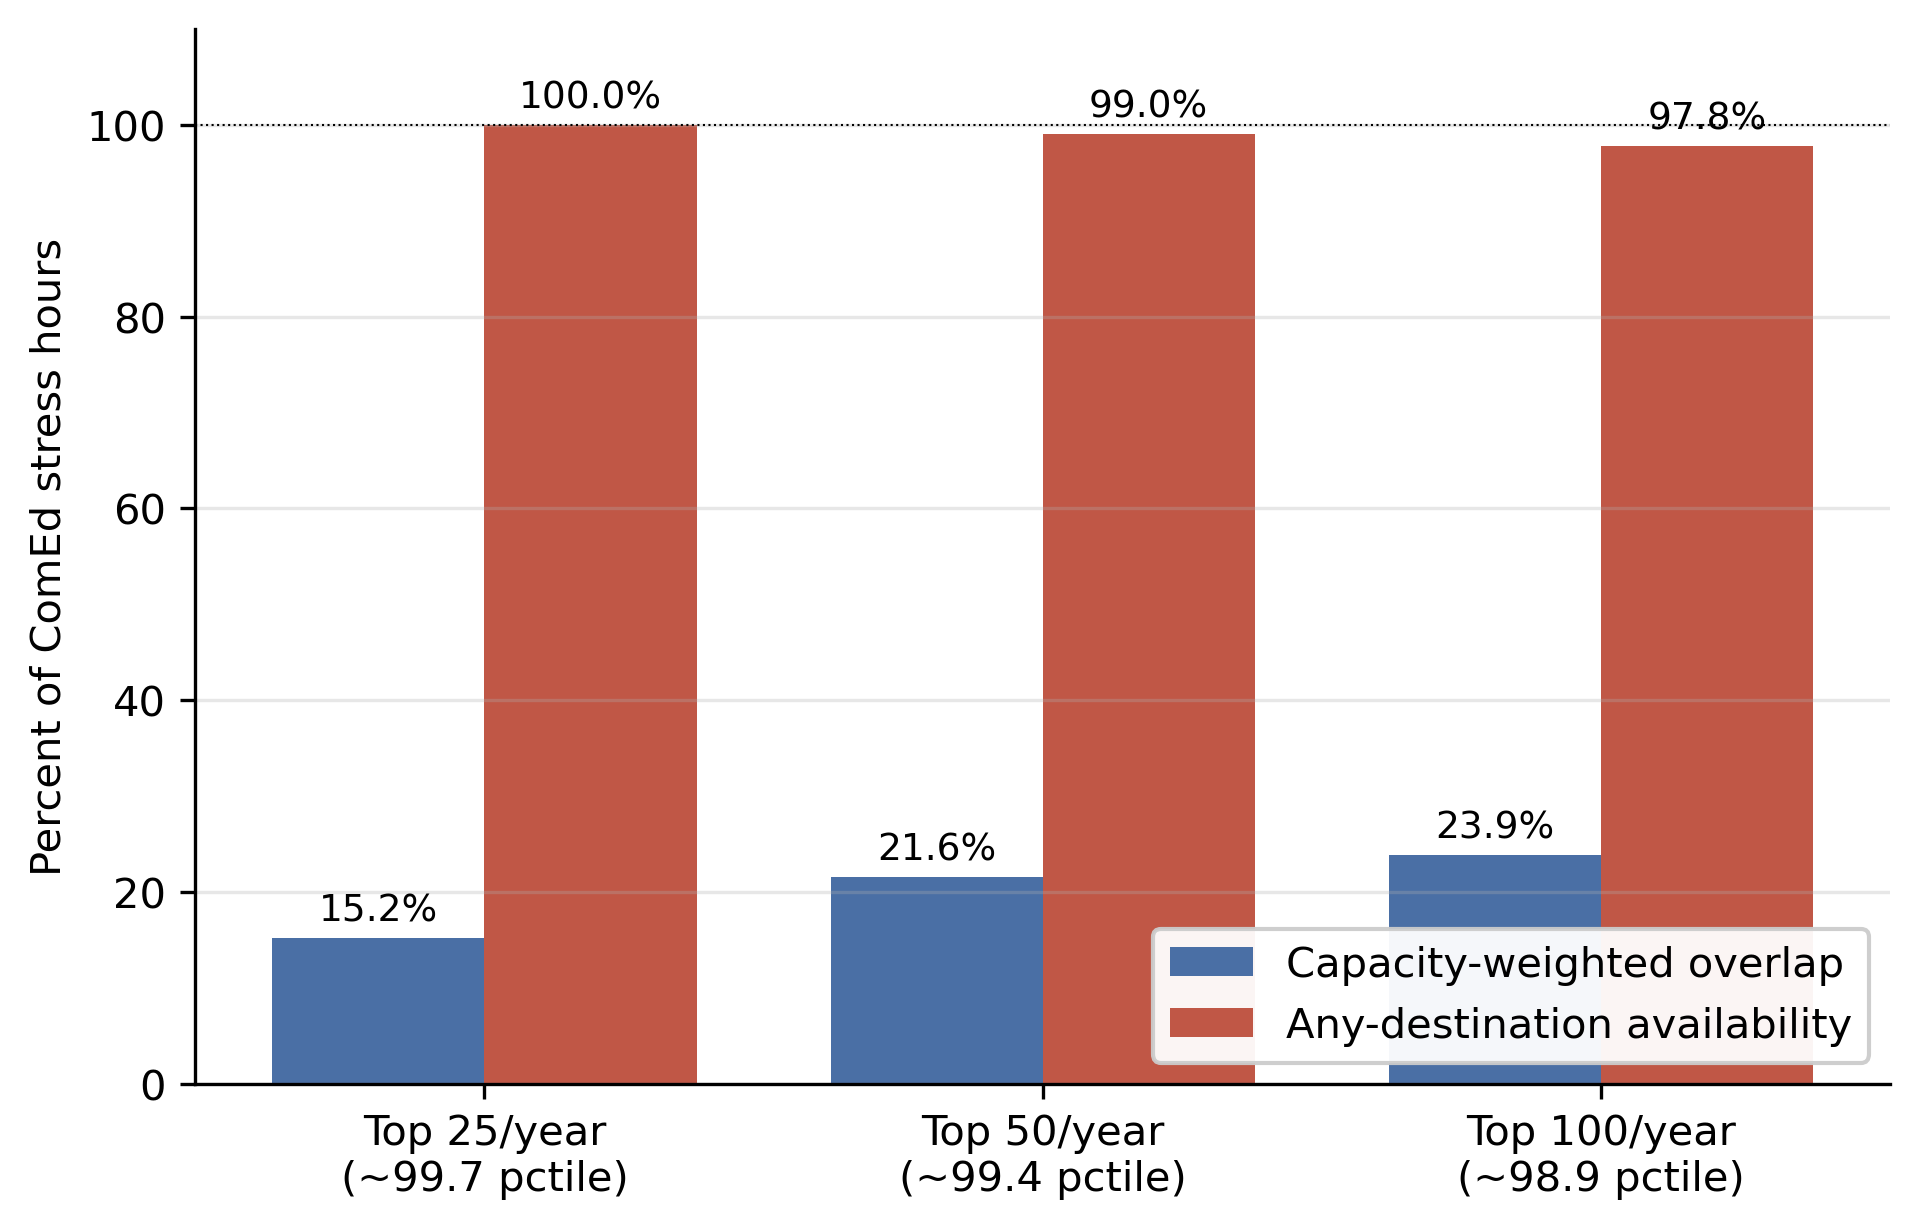

Saved figure: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\extended_data_fig1_threshold_sensitivity.png
Saved figure: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\extended_data_fig1_threshold_sensitivity.pdf
Saved table:  C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\tables\extended_data_table_threshold_sensitivity.csv

 Top N per year  Total ComEd stress hours  Approx. percentile  Capacity-weighted overlap (%)  Any-destination availability (%)  All destinations stressed (hours)  Baseline
             25                       100               99.71                          15.15                            100.00                                  0     False
             50                       200               99.43                          21.58                             99.00                                  2      True
            100                       400               98.86        

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-9: EXTENDED DATA FIG 1 + TABLE — THRESHOLD SENSITIVITY EXPORT
# ══════════════════════════════════════════════════════════════════════════════
# Writes Extended Data Fig. 1 (PNG + PDF) and the backing CSV table from the
# Cell 3-8 threshold sensitivity analysis.

import matplotlib.pyplot as plt
import pandas as pd

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=300)

top_ns = [v['top_n_per_year'] for v in threshold_sensitivity_results['variants']]
wtd = [v['capacity_weighted_overlap_pct'] for v in threshold_sensitivity_results['variants']]
avail = [v['any_destination_available_pct'] for v in threshold_sensitivity_results['variants']]
pctiles = [v['approx_percentile'] for v in threshold_sensitivity_results['variants']]

x = list(range(len(top_ns)))
bar_w = 0.38

bars1 = ax.bar([i - bar_w/2 for i in x], wtd, bar_w,
               label='Capacity-weighted overlap', color='#4a6fa5')
bars2 = ax.bar([i + bar_w/2 for i in x], avail, bar_w,
               label='Any-destination availability', color='#c05746')

for b, v in zip(bars1, wtd):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
for b, v in zip(bars2, avail):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Top {n}/year\n(~{p:.1f} pctile)' for n, p in zip(top_ns, pctiles)])
ax.set_ylabel('Percent of ComEd stress hours')
ax.set_ylim(0, 110)
ax.axhline(100, color='black', linewidth=0.5, linestyle=':')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

fig_path_png = REPO_ROOT / 'outputs' / 'figures' / 'extended_data_fig1_threshold_sensitivity.png'
fig_path_pdf = REPO_ROOT / 'outputs' / 'figures' / 'extended_data_fig1_threshold_sensitivity.pdf'
fig.savefig(fig_path_png, dpi=300, bbox_inches='tight')
fig.savefig(fig_path_pdf, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path_png}')
print(f'Saved figure: {fig_path_pdf}')

# ── Table ─────────────────────────────────────────────────────────────────────
ed_table_df = pd.DataFrame(threshold_sensitivity_results['variants'])
ed_table_df = ed_table_df[[
    'top_n_per_year',
    'total_source_stress_hours',
    'approx_percentile',
    'capacity_weighted_overlap_pct',
    'any_destination_available_pct',
    'all_destinations_stressed_hours',
    'is_baseline',
]]
ed_table_df.columns = [
    'Top N per year',
    'Total ComEd stress hours',
    'Approx. percentile',
    'Capacity-weighted overlap (%)',
    'Any-destination availability (%)',
    'All destinations stressed (hours)',
    'Baseline',
]

tbl_path = REPO_ROOT / 'outputs' / 'tables' / 'extended_data_table_threshold_sensitivity.csv'
ed_table_df.to_csv(tbl_path, index=False)
print(f'Saved table:  {tbl_path}')

print()
print(ed_table_df.to_string(index=False))

## Part 4: Contract Exports

Writes three files to `outputs/contracts/` that notebook 02 consumes:

1. **`stress_correlation_results.json`** — headline decorrelation numbers from Parts 1 and 3 (capacity-weighted overlap, dynamic availability, per-zone results, empirical destination LMPs, yearly stability)
2. **`per_hour_destination_availability.parquet`** — per-hour realized D1 vector across all ComEd stress hours, consumed by notebook 02's conditional Monte Carlo
3. **`workload_parameters.json`** — drain time statistics from Part 2, S3 parameterization justification

Running this Part overwrites all three files. Do not hand-edit them; regenerate by re-running this notebook.

In [15]:
import os
from pathlib import Path
# Resolve repo root so the notebook works whether launched from the repo root
# (VS Code default) or from notebooks/ (nbconvert default)
_cwd = Path.cwd()
if (_cwd / "notebooks").exists() and (_cwd / "data").exists():
    REPO_ROOT = _cwd                      # launched from repo root
elif _cwd.name == "notebooks":
    REPO_ROOT = _cwd.parent               # launched from notebooks/
else:
    REPO_ROOT = _cwd                      # fallback
print(f"REPO_ROOT resolved to: {REPO_ROOT}")
import pandas as pd
import numpy as np

REPO_ROOT resolved to: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy


### 4.1 Stress Correlation Results — JSON Contract

Headline decorrelation numbers, per-zone results, and yearly stability. This is the primary output of Parts 1 and 3. Schema version `1.0` — any schema change here must be mirrored in notebook 02's reader.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4-1: STRESS CORRELATION RESULTS — JSON CONTRACT
# ══════════════════════════════════════════════════════════════════════════════
# Output: outputs/contracts/stress_correlation_results.json
# Consumers: notebook 02 (cascade framework, conditional MC)
# Schema: docs/contract_schemas.md (version 1.0)
#
# Ported and cleaned from Cross_BA v5 Cell 6-1. Removed legacy v10 hand-patch
# instructions and paper summary print blocks that existed to support the old
# manual-update workflow.
# ══════════════════════════════════════════════════════════════════════════════

import json
import os

(REPO_ROOT / "outputs" / "contracts").mkdir(parents=True, exist_ok=True)

STRESS_JSON_PATH = REPO_ROOT / "outputs" / "contracts" / "stress_correlation_results.json"

stress_results = {
    'metadata': {
        'version': '1.0',
        'source_zone': SOURCE_ZONE,
        'top_n': TOP_N,
        'years': YEARS,
        'n_destination_zones': len(dest_results),
        'total_destination_mw': float(total_dest_mw),
        'produced_by': 'notebook 01 — empirical_evidence',
    },

    'headline': {
        'capacity_weighted_overlap_pct': float(weighted_overlap),
        'dynamic_availability_pct': float(pct_any_available),
        'all_stressed_pct': float(pct_all_stressed),
        'avg_intra_pjm_overlap_pct': float(avg_intra_pjm),
        'avg_cross_ba_overlap_pct': float(avg_cross_ba),
    },

    'empirical_destination_lmps': {
        'capacity_weighted_mean': float(weighted_mean),
        'capacity_weighted_median': float(weighted_median),
        'note': 'Replaces DESTINATION_LMP_CRISIS placeholder in cascade cost model',
    },

    'per_zone': dest_results,
    'yearly': yearly_results,
}

with open(STRESS_JSON_PATH, 'w') as f:
    json.dump(stress_results, f, indent=2, default=str)

print(f"Wrote {STRESS_JSON_PATH}")
print(f"  version:                 {stress_results['metadata']['version']}")
print(f"  source zone:             {stress_results['metadata']['source_zone']}")
print(f"  destination zones:       {stress_results['metadata']['n_destination_zones']}")
print(f"  capacity-weighted overlap: {stress_results['headline']['capacity_weighted_overlap_pct']:.1f}%")
print(f"  dynamic availability:      {stress_results['headline']['dynamic_availability_pct']:.1f}%")
print(f"  cap-weighted mean dest LMP: ${stress_results['empirical_destination_lmps']['capacity_weighted_mean']:.1f}")

Wrote C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\contracts\stress_correlation_results.json
  version:                 1.0
  source zone:             PJM_COMED
  destination zones:       17
  capacity-weighted overlap: 21.6%
  dynamic availability:      99.0%
  cap-weighted mean dest LMP: $165.5


### 4.2 Per-Hour Destination Availability — Parquet Contract

One row per ComEd stress hour. Each destination zone column contains either the zone's DC capacity (MW) if that zone was unstressed in that hour, or 0.0 if stressed. An additional `pjm_co_stressed_mw` column captures co-stressed PJM capacity (for the intra-PJM correlation that notebook 02 conditions on separately). This is the realized D1 vector that notebook 02's conditional Monte Carlo replaces the parametric D1 with.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4-2: PER-HOUR DESTINATION AVAILABILITY — PARQUET CONTRACT
# ══════════════════════════════════════════════════════════════════════════════
# Output: outputs/contracts/per_hour_destination_availability.parquet
# Consumers: notebook 02 (conditional Monte Carlo)
# Schema: one row per ComEd stress hour; columns = destination zones (MW) +
#         pjm_co_stressed_mw + timestamp
#
# DEFENSIVE: This cell recomputes source_stress_idx and cross_ba_zones from
# meta + stress_df rather than trusting the loop variables left behind by
# Cells 41/43, which shadow those names with their last iteration's values.
# ══════════════════════════════════════════════════════════════════════════════

PARQUET_PATH = REPO_ROOT / "outputs" / "contracts" / "per_hour_destination_availability.parquet"

# ── Recompute source stress index from scratch ────────────────────────────────
SOURCE = 'PJM_COMED'
_source_mask = stress_df[SOURCE].fillna(False).astype(bool)
_source_stress_idx = stress_df.index[_source_mask]

# ── Recompute zone lists from meta, intersected with available stress columns ─
_cross_ba_zones = [
    z for z in meta[meta.migration_role == 'cross_ba_destination'].index.tolist()
    if z in stress_df.columns
]
_pjm_zones = [
    z for z in meta[(meta.rto == 'PJM') & (meta.migration_role == 'intra_rto_control')].index.tolist()
    if z in stress_df.columns
]

print(f"Source:                  {SOURCE}")
print(f"Source stress hours:     {len(_source_stress_idx)}")
print(f"Cross-BA destinations:   {len(_cross_ba_zones)}")
print(f"  {_cross_ba_zones}")
print(f"Intra-PJM control:       {len(_pjm_zones)}")
print(f"  {_pjm_zones}")
print()

# ── Build the per-hour availability rows ──────────────────────────────────────
rows = []
for hour in _source_stress_idx:
    row = {'timestamp': hour}

    # Cross-BA destination availability: MW if unstressed, 0 if stressed
    for z in _cross_ba_zones:
        z_stressed = stress_df.loc[hour, z]
        if pd.isna(z_stressed) or not z_stressed:
            row[z] = float(meta.loc[z, 'dc_capacity_mw'])
        else:
            row[z] = 0.0

    # PJM co-stressed MW (aggregate, for intra-PJM correlation conditioning)
    pjm_costress = 0.0
    for z in _pjm_zones:
        if not pd.isna(stress_df.loc[hour, z]) and stress_df.loc[hour, z]:
            pjm_costress += float(meta.loc[z, 'dc_capacity_mw'])
    row['pjm_co_stressed_mw'] = pjm_costress

    rows.append(row)

avail_df = pd.DataFrame(rows)
avail_df.to_parquet(PARQUET_PATH, index=False)

print(f"Wrote {PARQUET_PATH}")
print(f"  rows (stress hours):     {len(avail_df):,}")
print(f"  columns (zones + meta):  {len(avail_df.columns)}")
print(f"  cross-BA destinations:   {len(_cross_ba_zones)}")
print(f"  PJM zones (aggregated):  {len(_pjm_zones)}")
print()
print("  Sample (first 3 rows, first 6 columns):")
print(avail_df.iloc[:3, :6].to_string(index=False))

Source:                  PJM_COMED
Source stress hours:     200
Cross-BA destinations:   17
  ['ERCOT_LZ_NORTH', 'ERCOT_LZ_SOUTH', 'ERCOT_LZ_WEST', 'ERCOT_LZ_HOUSTON', 'CAISO_NP15', 'CAISO_SP15', 'MISO_MINN_HUB', 'MISO_INDIANA_HUB', 'MISO_ILLINOIS_HUB', 'MISO_MICHIGAN_HUB', 'MISO_ARKANSAS_HUB', 'MISO_LOUISIANA_HUB', 'NYISO_ZONE_J', 'NYISO_ZONE_F', 'NYISO_ZONE_A', 'NYISO_ZONE_G', 'NYISO_ZONE_K']
Intra-PJM control:       6
  ['PJM_DOM', 'PJM_AEP', 'PJM_BGE', 'PJM_PECO', 'PJM_PEPCO', 'PJM_PSEG']

Wrote C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\contracts\per_hour_destination_availability.parquet
  rows (stress hours):     200
  columns (zones + meta):  19
  cross-BA destinations:   17
  PJM zones (aggregated):  6

  Sample (first 3 rows, first 6 columns):
          timestamp  ERCOT_LZ_NORTH  ERCOT_LZ_SOUTH  ERCOT_LZ_WEST  ERCOT_LZ_HOUSTON  CAISO_NP15
2022-06-14 14:00:00          4274.6          2866.1         2480.0             889.8      1310.7
2022-06-14 15:0

### 4.3 Workload Parameters — JSON Contract

Drain time statistics from Part 2 and the S3 parameterization. Notebook 02's cascade cell reads S3 from this file instead of hardcoding it, ensuring the empirical justification and the cascade value stay synchronized.

**If Azure data was not available in Cell 2-1**, this contract writes `null` for DynamoLLM P99 fields and the file can still be consumed by notebook 02 (which falls back to the paper-cited values).

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4-3: WORKLOAD PARAMETERS — JSON CONTRACT
# ══════════════════════════════════════════════════════════════════════════════
# Output: outputs/contracts/workload_parameters.json
# Consumers: notebook 02 (cascade parameter S3)
# Schema: version 1.0
# ══════════════════════════════════════════════════════════════════════════════

WORKLOAD_JSON_PATH = REPO_ROOT / "outputs" / "contracts" / "workload_parameters.json"

workload_contract = {
    'version': '1.0',
    'produced_by': 'notebook 01 — empirical_evidence',
    'throughput_assumption_tok_per_sec': THROUGHPUT_ASSUMPTION,

    'dynamolm': {
        'available': _AZURE_DATA_AVAILABLE,
        'n_requests': int(sum(len(df) for df in traces.values())) if _AZURE_DATA_AVAILABLE else None,
        'date_range_source': 'Azure internal production, 7 days in May 2024',
        'p99_drain_time_coding_sec': dynamolm_p99_drain_coding,
        'p99_drain_time_conv_sec': dynamolm_p99_drain_conv,
        'citation': 'Stojkovic et al. HPCA 2025 (DynamoLLM)',
    },

    'burstgpt': {
        'available': True,
        'n_requests': burstgpt_n_requests,
        'date_range': burstgpt_date_range,
        'date_range_source': 'Azure OpenAI regional endpoints',
        'p99_drain_time_sec': burstgpt_p99_drain,
        'citation': 'Wang et al. 2024 (BurstGPT)',
    },

    's3_parameterization': {
        'value': 0.90,
        'justification': (
            'P99 drain times across two independent datasets range from '
            '4.5 to 12.1 seconds at 60 tok/s, approximately two orders of '
            'magnitude below PJM 10-minute dispatch window. S3 = 0.90 '
            'reserves 10% of load for long-running or batched requests.'
        ),
        'pjm_dispatch_window_seconds': 600,
    },
}

with open(WORKLOAD_JSON_PATH, 'w') as f:
    json.dump(workload_contract, f, indent=2, default=str)

print(f"Wrote {WORKLOAD_JSON_PATH}")
print(f"  version:                    {workload_contract['version']}")
print(f"  DynamoLLM available:        {workload_contract['dynamolm']['available']}")
if _AZURE_DATA_AVAILABLE:
    print(f"  DynamoLLM P99 (Coding):     {workload_contract['dynamolm']['p99_drain_time_coding_sec']:.2f}s")
    print(f"  DynamoLLM P99 (Conv):       {workload_contract['dynamolm']['p99_drain_time_conv_sec']:.2f}s")
print(f"  BurstGPT P99:               {workload_contract['burstgpt']['p99_drain_time_sec']:.2f}s")
print(f"  S3 parameterization:        {workload_contract['s3_parameterization']['value']}")

Wrote C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\contracts\workload_parameters.json
  version:                    1.0
  DynamoLLM available:        True
  DynamoLLM P99 (Coding):     4.52s
  DynamoLLM P99 (Conv):       11.57s
  BurstGPT P99:               12.12s
  S3 parameterization:        0.9
